
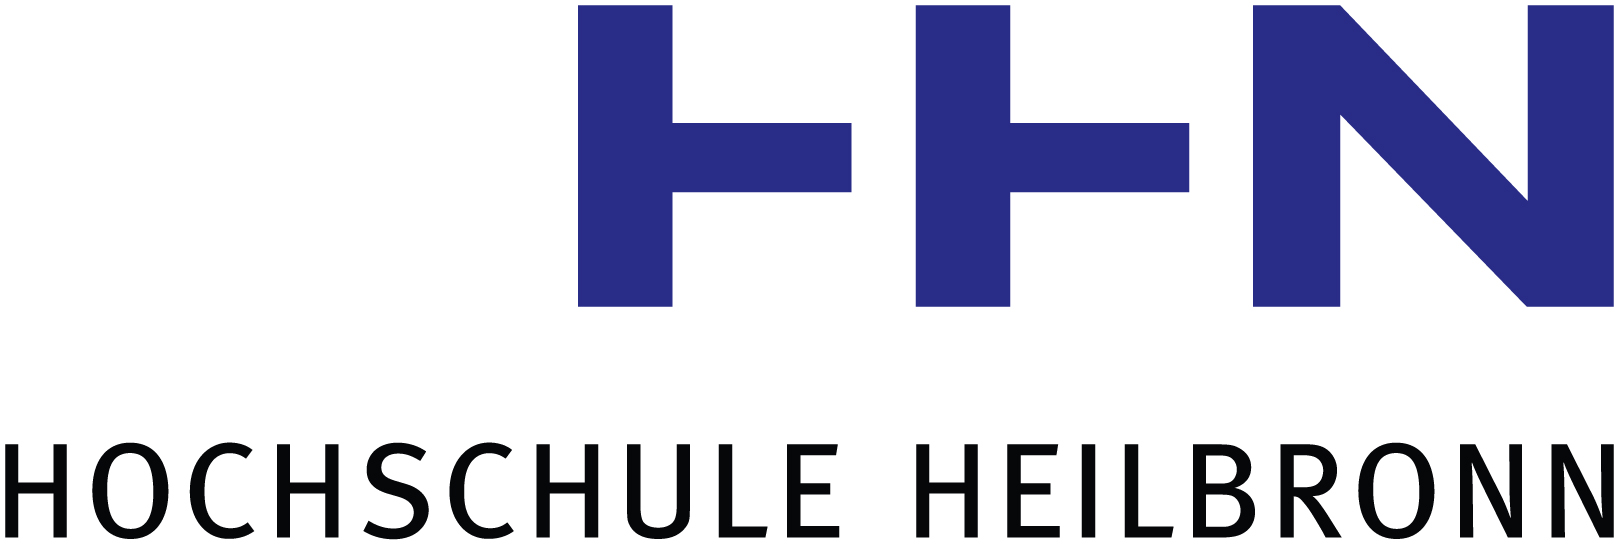


**MWI - Deep Learning**


# RQ2 (Portfolio Examination)

## Beyond Clean Data
#### *Comparing MLP and CNN Robustness to Image Perturbations*

**Due Date:** April 16, 2026  
**Team:** [Your Team Name]  
**Members:** [Name 1, Name 2]  


---

### Research Question

> *How do MLP and CNN differ in their robustness to systematic image perturbations on MNIST, and which types of perturbation cause which model to fail?*

---

**How to use this template:**
- This notebook runs **out of the box** and trains both an MLP and a CNN on MNIST.
- Look for `# TODO` markers -- these are the places where you need to add your experiments.
- The template provides: model definitions, training loop, perturbation helpers, and plotting functions.
- You should **reuse your training knowledge from RQ1** -- the loop is similar but simplified (no regularization focus).
- Your main creative work: **designing perturbations** and **analyzing failures**.

## 1. Setup and Imports

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split
import torchvision
import torchvision.transforms as transforms
import torchvision.transforms.functional as TF

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from copy import deepcopy
from PIL import Image
import scipy.ndimage
import os

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# Plot style
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

Using device: cuda


## 2. Data Loading

We load MNIST and split into **train** (50,000), **validation** (10,000), and **test** (10,000).  
The test set is what we will perturb later -- the models never see any perturbed data during training.

Training samples:   50000
Validation samples: 10000
Test samples:       10000
Test images shape: torch.Size([10000, 28, 28])


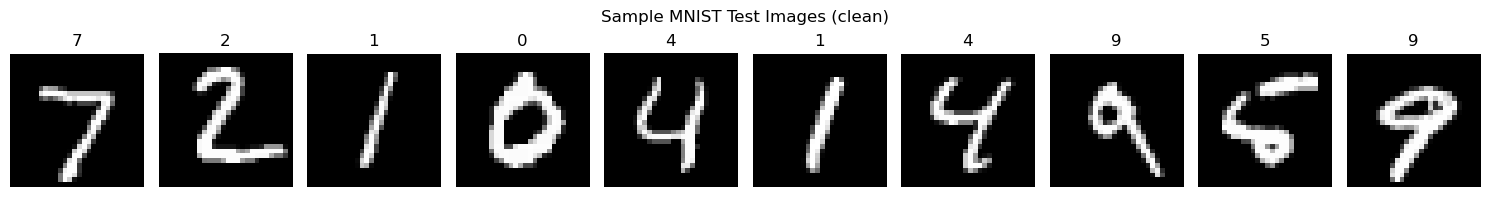

In [2]:
# MNIST normalization: mean=0.1307, std=0.3081
MNIST_MEAN = 0.1307
MNIST_STD = 0.3081

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((MNIST_MEAN,), (MNIST_STD,))
])

full_train_dataset = torchvision.datasets.MNIST(
    root='./data', train=True, download=True, transform=transform
)
test_dataset = torchvision.datasets.MNIST(
    root='./data', train=False, download=True, transform=transform
)

train_dataset, val_dataset = random_split(
    full_train_dataset, [50000, 10000],
    generator=torch.Generator().manual_seed(SEED)
)

BATCH_SIZE = 128
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f'Training samples:   {len(train_dataset)}')
print(f'Validation samples: {len(val_dataset)}')
print(f'Test samples:       {len(test_dataset)}')

# Also extract raw test images and labels as tensors (for perturbation later)
test_images = test_dataset.data.float() / 255.0   # [10000, 28, 28], range [0, 1]
test_labels = test_dataset.targets                  # [10000]
print(f'Test images shape: {test_images.shape}')

# Show sample images
fig, axes = plt.subplots(1, 10, figsize=(15, 2))
for i, ax in enumerate(axes):
    ax.imshow(test_images[i], cmap='gray')
    ax.set_title(f'{test_labels[i].item()}')
    ax.axis('off')
plt.suptitle('Sample MNIST Test Images (clean)')
plt.tight_layout()
plt.show()

## 3. Model Definitions

We define both an MLP and a CNN. Both are kept simple and train quickly on MNIST.

In [3]:
class MLP(nn.Module):
    """Multi-Layer Perceptron for MNIST.
    Flattens the 28x28 image and processes it through fully-connected layers.
    """
    def __init__(self, hidden_size=256, num_layers=2):
        super().__init__()
        layers = []
        in_features = 784  # 28 * 28
        for _ in range(num_layers):
            layers.extend([nn.Linear(in_features, hidden_size), nn.ReLU()])
            in_features = hidden_size
        layers.append(nn.Linear(in_features, 10))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        x = x.view(x.size(0), -1)  # Flatten
        return self.network(x)

    def count_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


class CNN(nn.Module):
    """Simple CNN for MNIST.
    Uses convolutional layers to detect local features, then classifies.
    """
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            # Conv block 1: 1 -> 16 channels
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 28x28 -> 14x14
            # Conv block 2: 16 -> 32 channels
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 14x14 -> 7x7
            # Conv block 3: 32 -> 64 channels
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 7x7 -> 3x3
        )
        self.classifier = nn.Sequential(
            nn.Linear(64 * 3 * 3, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        if x.dim() == 3:  # [B, 28, 28] -> [B, 1, 28, 28]
            x = x.unsqueeze(1)
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)

    def count_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


# Quick check
mlp = MLP(hidden_size=256, num_layers=2)
cnn = CNN()
print(f'MLP parameters: {mlp.count_parameters():,}')
print(f'CNN parameters: {cnn.count_parameters():,}')

MLP parameters: 269,322
CNN parameters: 98,442


## 4. Training and Evaluation Functions

A simple training loop (similar to RQ1, but without regularization options -- the focus here is robustness, not overfitting).

In [4]:
def train_model(model, train_loader, val_loader, num_epochs=20, lr=0.001, verbose=True):
    """Train a model on MNIST. Returns history dict and best validation accuracy."""
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_acc = 0.0
    best_state = None

    for epoch in range(1, num_epochs + 1):
        # Train
        model.train()
        total_loss, correct, total = 0.0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
        train_loss = total_loss / total
        train_acc = 100.0 * correct / total

        # Validate
        model.eval()
        total_loss, correct, total = 0.0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                total_loss += loss.item() * images.size(0)
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()
        val_loss = total_loss / total
        val_acc = 100.0 * correct / total

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = deepcopy(model.state_dict())

        if verbose and (epoch % 5 == 0 or epoch == 1):
            print(f'Epoch {epoch:2d}/{num_epochs} | '
                  f'Train {train_acc:.2f}% | Val {val_acc:.2f}%')

    if best_state:
        model.load_state_dict(best_state)
    return history, best_val_acc


def evaluate_model(model, data_loader):
    """Evaluate model and return accuracy, predictions, and true labels."""
    model.eval()
    all_preds, all_labels = [], []
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    accuracy = 100.0 * correct / total
    return accuracy, np.array(all_preds), np.array(all_labels)

## 5. Train Baseline Models

Train both models on clean MNIST (no data augmentation). Both should reach >98% test accuracy.

In [5]:
# Train MLP
print('=' * 60)
print('Training MLP (2 layers, 256 neurons)')
print('=' * 60)
mlp_model = MLP(hidden_size=256, num_layers=2)
mlp_history, mlp_best = train_model(mlp_model, train_loader, val_loader, num_epochs=20)
mlp_test_acc, mlp_preds, mlp_true = evaluate_model(mlp_model, test_loader)
print(f'MLP Test Accuracy: {mlp_test_acc:.2f}%')

print()

# Train CNN
print('=' * 60)
print('Training CNN')
print('=' * 60)
cnn_model = CNN()
cnn_history, cnn_best = train_model(cnn_model, train_loader, val_loader, num_epochs=20)
cnn_test_acc, cnn_preds, cnn_true = evaluate_model(cnn_model, test_loader)
print(f'CNN Test Accuracy: {cnn_test_acc:.2f}%')

print(f'\nBaseline summary: MLP={mlp_test_acc:.2f}%, CNN={cnn_test_acc:.2f}%')

Training MLP (2 layers, 256 neurons)
Epoch  1/20 | Train 91.66% | Val 95.30%
Epoch  5/20 | Train 98.79% | Val 97.13%
Epoch 10/20 | Train 99.32% | Val 97.72%
Epoch 15/20 | Train 99.66% | Val 97.80%
Epoch 20/20 | Train 99.73% | Val 97.55%
MLP Test Accuracy: 98.03%

Training CNN
Epoch  1/20 | Train 92.04% | Val 97.43%
Epoch  5/20 | Train 99.08% | Val 98.55%
Epoch 10/20 | Train 99.62% | Val 99.03%
Epoch 15/20 | Train 99.70% | Val 98.99%
Epoch 20/20 | Train 99.73% | Val 99.06%
CNN Test Accuracy: 99.11%

Baseline summary: MLP=98.03%, CNN=99.11%


---

## 6. Perturbation Functions

Helper functions for applying perturbations to MNIST test images.  
One example perturbation (rotation) is provided. **You add the rest.**

All perturbation functions follow the same signature:
- **Input:** `images` tensor of shape `[N, 28, 28]` with values in `[0, 1]`
- **Input:** perturbation-specific parameter(s) controlling intensity
- **Output:** perturbed `images` tensor of same shape, values clipped to `[0, 1]`

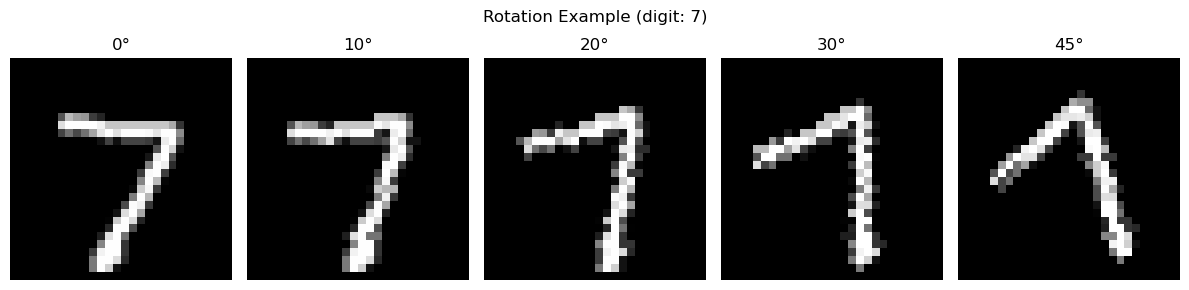

In [6]:
def perturb_rotation(images, angle_degrees):
    """Rotate each image by a fixed angle (in degrees)."""
    rotated = torch.zeros_like(images)
    for i in range(len(images)):
        img_pil = TF.to_pil_image(images[i].unsqueeze(0))  # [1, 28, 28]
        img_pil = TF.rotate(img_pil, angle_degrees, fill=0)
        rotated[i] = TF.to_tensor(img_pil).squeeze(0)
    return rotated


# Additional perturbation functions used in the experiments below:

def perturb_translation(images, shift_pixels):
    """Shift images by shift_pixels in x and y direction."""
    shifted = torch.zeros_like(images)
    for i in range(len(images)):
        img_pil = TF.to_pil_image(images[i].unsqueeze(0))  # [1, 28, 28]
        img_pil = TF.affine(img_pil, angle=0, translate=shift_pixels, scale=1.0, shear=0, fill=0)
        shifted[i] = TF.to_tensor(img_pil).squeeze(0)
    return shifted

def perturb_noise(images, noise_std):
    """Add Gaussian noise with given standard deviation."""
    noise = torch.randn_like(images) * noise_std
    noisy_images = images + noise
    return torch.clamp(noisy_images, 0.0, 1.0)

def perturb_blur(images, sigma):
    """Apply Gaussian blur with given sigma."""
    blurred = torch.zeros_like(images)
    for i in range(len(images)):
        img_np = images[i].numpy()
        img_blurred = scipy.ndimage.gaussian_filter(img_np, sigma=sigma)
        blurred[i] = torch.from_numpy(img_blurred)
    return blurred

def perturb_erosion(images, level):
    """Soft grayscale erosion with fractional strength."""
    eroded = torch.zeros_like(images)

    for i in range(len(images)):
        img_np = images[i].numpy().astype(np.float32)

        whole = int(np.floor(level))
        frac = level - whole

        out = img_np.copy()

        # Apply full erosion steps
        for _ in range(whole):
            out = scipy.ndimage.grey_erosion(out, size=(3, 3))

        # Interpolate for fractional steps
        if frac > 0:
            next_out = scipy.ndimage.grey_erosion(out, size=(3, 3))
            out = (1 - frac) * out + frac * next_out

        eroded[i] = torch.from_numpy(np.clip(out, 0.0, 1.0))

    return eroded

def perturb_inversion(images):
    """Invert colors: white digit on black -> black digit on white."""
    return 1.0 - images

# Be creative! You can also combine perturbations.


# Quick visual check: show rotation example
angles = [0, 10, 20, 30, 45]
fig, axes = plt.subplots(1, len(angles), figsize=(12, 3))
sample_img = test_images[:1]  # Take first test image
for ax, angle in zip(axes, angles):
    if angle == 0:
        ax.imshow(sample_img[0], cmap='gray')
    else:
        ax.imshow(perturb_rotation(sample_img, angle)[0], cmap='gray')
    ax.set_title(f'{angle}°')
    ax.axis('off')
plt.suptitle(f'Rotation Example (digit: {test_labels[0].item()})')
plt.tight_layout()
plt.show()

## 7. Evaluating Models on Perturbed Data

Helper function to evaluate a trained model on a perturbed test set.  
Perturbed images (in `[0, 1]` range) are normalized to match the training distribution before evaluation.

In [7]:
def evaluate_on_perturbed(model, perturbed_images, labels, batch_size=128):
    """Evaluate a trained model on perturbed images.

    Args:
        model: Trained model (MLP or CNN).
        perturbed_images: Tensor [N, 28, 28], values in [0, 1].
        labels: Tensor [N] of true labels.
        batch_size: Batch size for evaluation.

    Returns:
        accuracy: Overall accuracy (%).
        per_class_acc: Dict mapping class -> accuracy (%).
        all_preds: Array of predictions.
        all_labels: Array of true labels.
    """
    # Normalize to match training distribution
    normalized = (perturbed_images - MNIST_MEAN) / MNIST_STD
    normalized = normalized.unsqueeze(1)  # [N, 1, 28, 28]

    dataset = TensorDataset(normalized, labels)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

    model.eval()
    all_preds, all_labels_list = [], []
    correct, total = 0, 0

    with torch.no_grad():
        for imgs, lbls in loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            outputs = model(imgs)
            _, predicted = outputs.max(1)
            correct += predicted.eq(lbls).sum().item()
            total += lbls.size(0)
            all_preds.extend(predicted.cpu().numpy())
            all_labels_list.extend(lbls.cpu().numpy())

    accuracy = 100.0 * correct / total
    all_preds = np.array(all_preds)
    all_labels_arr = np.array(all_labels_list)

    # Per-class accuracy
    per_class_acc = {}
    for c in range(10):
        mask = all_labels_arr == c
        if mask.sum() > 0:
            per_class_acc[c] = 100.0 * (all_preds[mask] == c).sum() / mask.sum()

    return accuracy, per_class_acc, all_preds, all_labels_arr

## 8. Plotting Functions

Ready-to-use visualizations for comparing MLP vs. CNN robustness.

In [8]:
def plot_degradation_curve(intensities, mlp_accs, cnn_accs, xlabel, title):
    """Plot accuracy vs. perturbation intensity for MLP and CNN."""
    plt.figure(figsize=(8, 5))
    plt.plot(intensities, mlp_accs, 'o-', label='MLP', linewidth=2, markersize=8)
    plt.plot(intensities, cnn_accs, 's-', label='CNN', linewidth=2, markersize=8)
    plt.xlabel(xlabel)
    plt.ylabel('Accuracy (%)')
    plt.title(title)
    plt.legend()
    plt.ylim(0, 105)
    plt.tight_layout()
    plt.show()


def plot_confusion_matrix(true_labels, predictions, title='Confusion Matrix'):
    """Plot a confusion matrix."""
    cm = confusion_matrix(true_labels, predictions, labels=range(10))
    fig, ax = plt.subplots(figsize=(8, 7))
    disp = ConfusionMatrixDisplay(cm, display_labels=range(10))
    disp.plot(ax=ax, cmap='Blues', values_format='d')
    ax.set_title(title)
    plt.tight_layout()
    plt.show()


def plot_per_class_comparison(mlp_per_class, cnn_per_class, title='Per-Class Accuracy'):
    """Side-by-side bar chart of per-class accuracy for MLP and CNN."""
    classes = list(range(10))
    mlp_vals = [mlp_per_class.get(c, 0) for c in classes]
    cnn_vals = [cnn_per_class.get(c, 0) for c in classes]

    x = np.arange(10)
    width = 0.35
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(x - width/2, mlp_vals, width, label='MLP', color='steelblue')
    ax.bar(x + width/2, cnn_vals, width, label='CNN', color='darkorange')
    ax.set_xlabel('Digit Class')
    ax.set_ylabel('Accuracy (%)')
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(classes)
    ax.legend()
    ax.set_ylim(0, 105)
    plt.tight_layout()
    plt.show()


def show_failure_examples(images, true_labels, predictions, model_name,
                          n_examples=10, title=None):
    """Show examples where the model made wrong predictions."""
    wrong = np.where(predictions != true_labels)[0]
    if len(wrong) == 0:
        print(f'{model_name}: No errors found!')
        return
    indices = wrong[:n_examples]
    fig, axes = plt.subplots(1, len(indices), figsize=(2 * len(indices), 3))
    if len(indices) == 1:
        axes = [axes]
    for ax, idx in zip(axes, indices):
        ax.imshow(images[idx], cmap='gray')
        ax.set_title(f'True: {true_labels[idx]}\nPred: {predictions[idx]}',
                     color='red', fontsize=10)
        ax.axis('off')
    plt.suptitle(title or f'{model_name} -- Failure Examples', fontsize=12)
    plt.tight_layout()
    plt.show()


def get_confusion_details(true_labels, predictions):
    """Return the confusion matrix and a sorted DataFrame of off-diagonal confusions."""
    cm = confusion_matrix(true_labels, predictions, labels=range(10))
    rows = []
    for true_digit in range(10):
        true_total = int(cm[true_digit].sum())
        if true_total == 0:
            continue
        for pred_digit in range(10):
            if true_digit == pred_digit:
                continue
            count = int(cm[true_digit, pred_digit])
            if count > 0:
                rows.append({
                    'true_digit': true_digit,
                    'pred_digit': pred_digit,
                    'count': count,
                    'true_total': true_total,
                    'rate_within_true_class': 100.0 * count / true_total,
                })

    if rows:
        details = pd.DataFrame(rows).sort_values(
            ['rate_within_true_class', 'count'], ascending=[False, False]
        ).reset_index(drop=True)
    else:
        details = pd.DataFrame(columns=['true_digit', 'pred_digit', 'count', 'true_total', 'rate_within_true_class'])
    return cm, details


def print_top_confusions(true_labels, predictions, title='Top Confusions', top_k=5):
    """Print the most frequent off-diagonal confusion pairs."""
    _, details = get_confusion_details(true_labels, predictions)
    print(title)
    if details.empty:
        print('  No off-diagonal confusions found.')
        return

    for row in details.head(top_k).itertuples(index=False):
        print(
            f'  true {row.true_digit} -> pred {row.pred_digit}: '
            f'{row.count} samples ({row.rate_within_true_class:.2f}% of class {row.true_digit})'
        )


def print_target_confusion(true_labels, predictions, true_digit, pred_digit, title=None):
    """Print a targeted confusion such as 6 -> 9 with absolute and relative counts."""
    cm, _ = get_confusion_details(true_labels, predictions)
    count = int(cm[true_digit, pred_digit])
    total = int(cm[true_digit].sum())
    rate = 100.0 * count / total if total > 0 else 0.0
    print(title or f'Confusion {true_digit} -> {pred_digit}')
    print(f'  {count} of {total} true {true_digit} samples were predicted as {pred_digit} ({rate:.2f}%).')


def scan_confusions_across_levels(model, images, labels, perturbation_name, intensities, perturbation_fn, formatter=None):
    """Evaluate one perturbation across several intensities and collect all off-diagonal confusions."""
    rows = []
    artifacts = {}
    for intensity in intensities:
        perturbed = perturbation_fn(images, intensity)
        accuracy, _, predictions, true_labels = evaluate_on_perturbed(model, perturbed, labels)
        display_intensity = formatter(intensity) if formatter else intensity
        artifacts[display_intensity] = {
            'images': perturbed.numpy(),
            'predictions': predictions,
            'true_labels': true_labels,
            'accuracy': accuracy,
        }

        _, details = get_confusion_details(true_labels, predictions)
        for row in details.itertuples(index=False):
            rows.append({
                'perturbation': perturbation_name,
                'intensity': display_intensity,
                'accuracy': accuracy,
                'true_digit': row.true_digit,
                'pred_digit': row.pred_digit,
                'confusion_count': row.count,
                'true_total': row.true_total,
                'rate_within_true_class': row.rate_within_true_class,
            })

    if rows:
        summary = pd.DataFrame(rows).sort_values(
            ['rate_within_true_class', 'confusion_count'], ascending=[False, False]
        ).reset_index(drop=True)
    else:
        summary = pd.DataFrame(columns=[
            'perturbation', 'intensity', 'accuracy', 'true_digit', 'pred_digit',
            'confusion_count', 'true_total', 'rate_within_true_class'
        ])
    return summary, artifacts


def show_target_confusion_examples(images, true_labels, predictions, true_digit, pred_digit, n_examples=6, title=None):
    """Show examples for one specific confusion pair, e.g. true 6 predicted as 9."""
    mask = (true_labels == true_digit) & (predictions == pred_digit)
    indices = np.where(mask)[0][:n_examples]
    if len(indices) == 0:
        print(title or f'Examples for {true_digit} -> {pred_digit}')
        print('  No examples found for this confusion pair.')
        return

    fig, axes = plt.subplots(1, len(indices), figsize=(2 * len(indices), 3))
    if len(indices) == 1:
        axes = [axes]
    for ax, idx in zip(axes, indices):
        ax.imshow(images[idx], cmap='gray')
        ax.set_title(f'True: {true_digit}\nPred: {pred_digit}', color='red', fontsize=10)
        ax.axis('off')
    plt.suptitle(title or f'Examples for {true_digit} -> {pred_digit}', fontsize=12)
    plt.tight_layout()
    plt.show()

## 9. Results Collection

Use this DataFrame to systematically collect all experiment results.

In [9]:
results = pd.DataFrame(columns=[
    'perturbation',      # e.g. 'rotation', 'noise', 'shift'
    'intensity',       # e.g. 15 (degrees), 0.3 (noise std), 3 (pixels)
    'mlp_accuracy',    # MLP accuracy on perturbed set
    'cnn_accuracy',    # CNN accuracy on perturbed set
    'accuracy_diff',   # CNN - MLP (positive = CNN better)
])

# Add baseline (clean test set) as first row
results.loc[len(results)] = ['clean', 0, mlp_test_acc, cnn_test_acc,
                              cnn_test_acc - mlp_test_acc]
print(results.to_string(index=False))

perturbation  intensity  mlp_accuracy  cnn_accuracy  accuracy_diff
       clean          0         98.03         99.11           1.08


---

## 10. Experiment 1: Rotation

This experiment is provided as a **complete example** to show the workflow.  
For your own perturbation types, follow the same pattern.

Evaluating rotation = 5°...
  MLP: 97.42%  |  CNN: 98.78%
Evaluating rotation = 10°...
  MLP: 96.27%  |  CNN: 98.31%
Evaluating rotation = 15°...
  MLP: 94.59%  |  CNN: 97.55%
Evaluating rotation = 20°...
  MLP: 90.70%  |  CNN: 95.50%
Evaluating rotation = 30°...
  MLP: 77.60%  |  CNN: 85.96%
Evaluating rotation = 45°...
  MLP: 49.77%  |  CNN: 60.90%
Evaluating rotation = 90°...
  MLP: 10.73%  |  CNN: 16.48%
Evaluating rotation = 180°...
  MLP: 30.91%  |  CNN: 37.06%


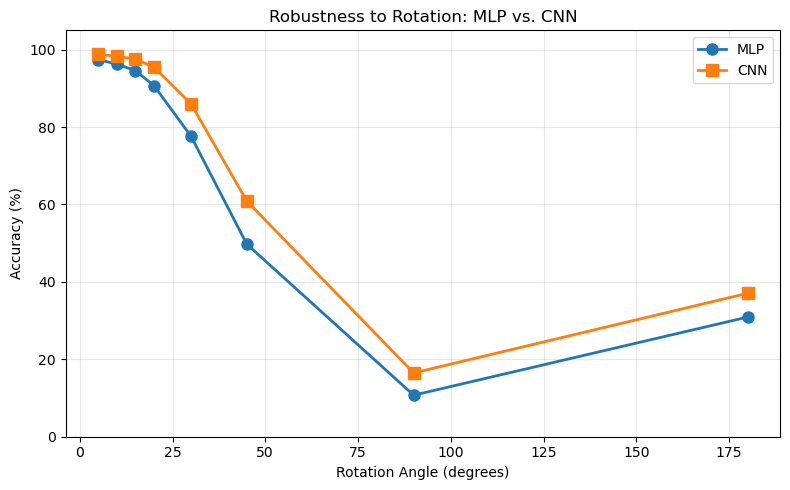

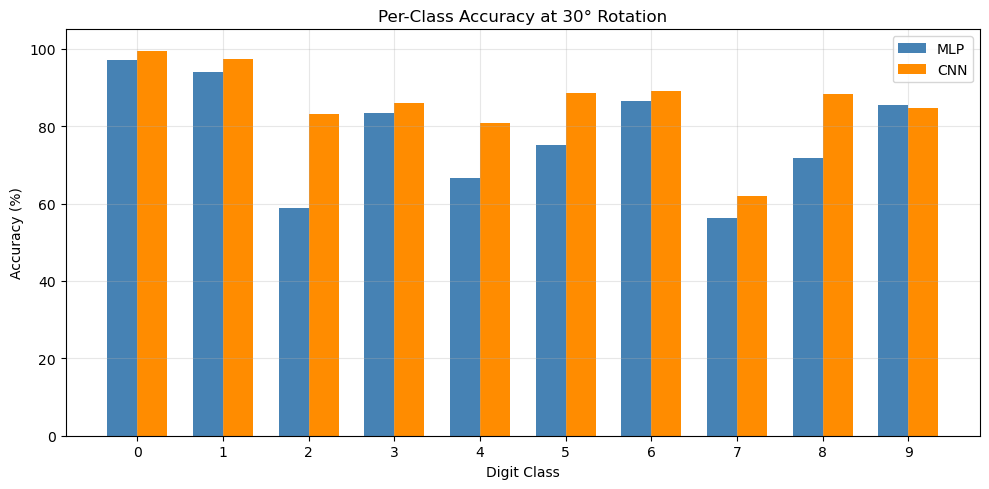

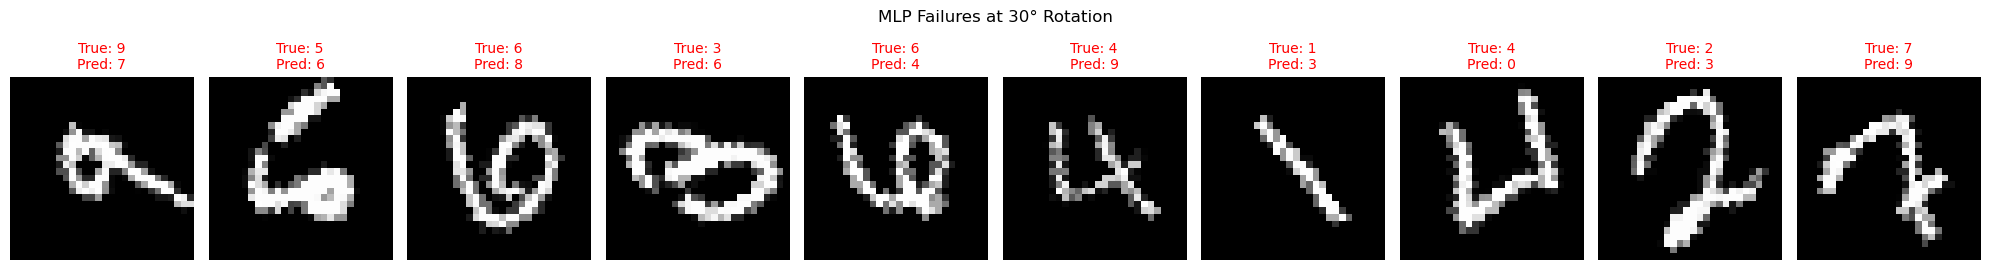

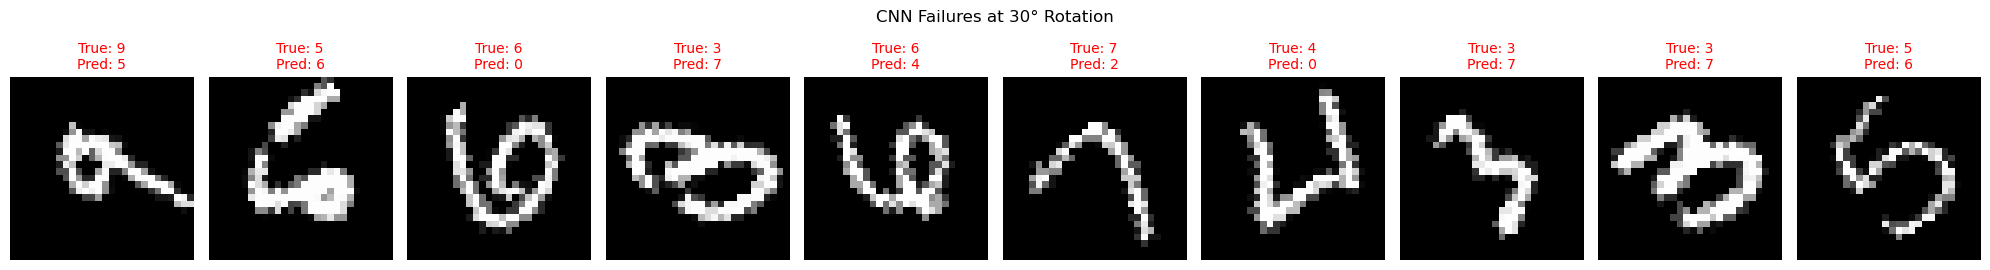

In [10]:
# Example experiment: Rotation at multiple angles
rotation_angles = [5, 10, 15, 20, 30, 45, 90, 180]
mlp_rot_accs, cnn_rot_accs = [], []

for angle in rotation_angles:
    print(f'Evaluating rotation = {angle}°...')
    perturbed = perturb_rotation(test_images, angle)

    mlp_acc, mlp_pc, mlp_pr, mlp_tr = evaluate_on_perturbed(mlp_model, perturbed, test_labels)
    cnn_acc, cnn_pc, cnn_pr, cnn_tr = evaluate_on_perturbed(cnn_model, perturbed, test_labels)

    mlp_rot_accs.append(mlp_acc)
    cnn_rot_accs.append(cnn_acc)

    results.loc[len(results)] = ['rotation', angle, mlp_acc, cnn_acc, cnn_acc - mlp_acc]
    print(f'  MLP: {mlp_acc:.2f}%  |  CNN: {cnn_acc:.2f}%')

# Plot degradation curve
plot_degradation_curve(rotation_angles, mlp_rot_accs, cnn_rot_accs,
                       xlabel='Rotation Angle (degrees)',
                       title='Robustness to Rotation: MLP vs. CNN')

# Show per-class accuracy at 30° rotation
perturbed_30 = perturb_rotation(test_images, 30)
_, mlp_pc_30, mlp_pr_30, mlp_tr_30 = evaluate_on_perturbed(mlp_model, perturbed_30, test_labels)
_, cnn_pc_30, cnn_pr_30, cnn_tr_30 = evaluate_on_perturbed(cnn_model, perturbed_30, test_labels)
plot_per_class_comparison(mlp_pc_30, cnn_pc_30, title='Per-Class Accuracy at 30° Rotation')

# Show some failure examples
show_failure_examples(perturbed_30.numpy(), mlp_tr_30, mlp_pr_30, 'MLP',
                      title='MLP Failures at 30° Rotation')
show_failure_examples(perturbed_30.numpy(), cnn_tr_30, cnn_pr_30, 'CNN',
                      title='CNN Failures at 30° Rotation')

---

## 11. Experiment 2: Translation

Translation probes how strongly each model depends on the exact pixel position of digit strokes.

Evaluating translation = (1, 1) pixels...
  MLP: 91.21%  |  CNN: 98.22%
Evaluating translation = (2, 2) pixels...
  MLP: 56.89%  |  CNN: 92.49%
Evaluating translation = (3, 3) pixels...
  MLP: 21.27%  |  CNN: 72.22%
Evaluating translation = (4, 4) pixels...
  MLP: 6.16%  |  CNN: 39.17%
Evaluating translation = (5, 5) pixels...
  MLP: 3.25%  |  CNN: 12.81%


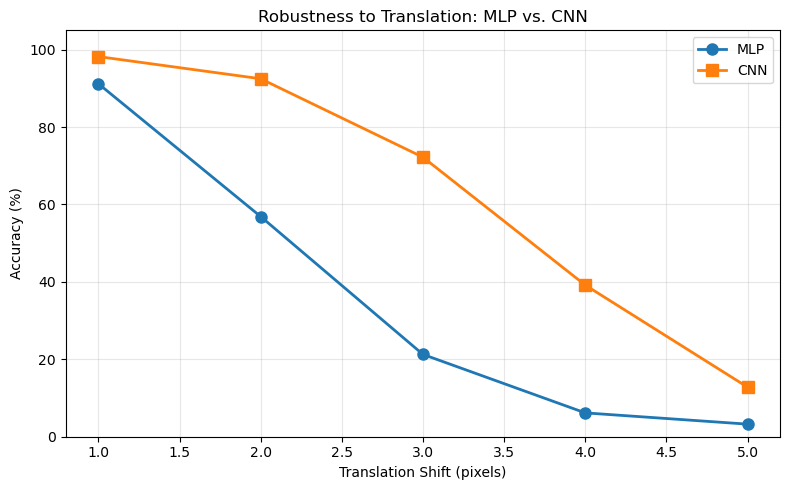

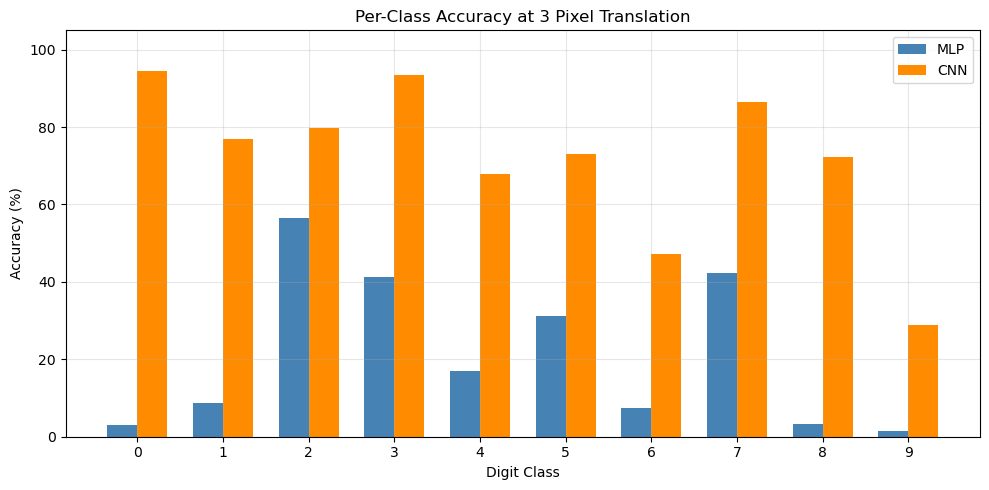

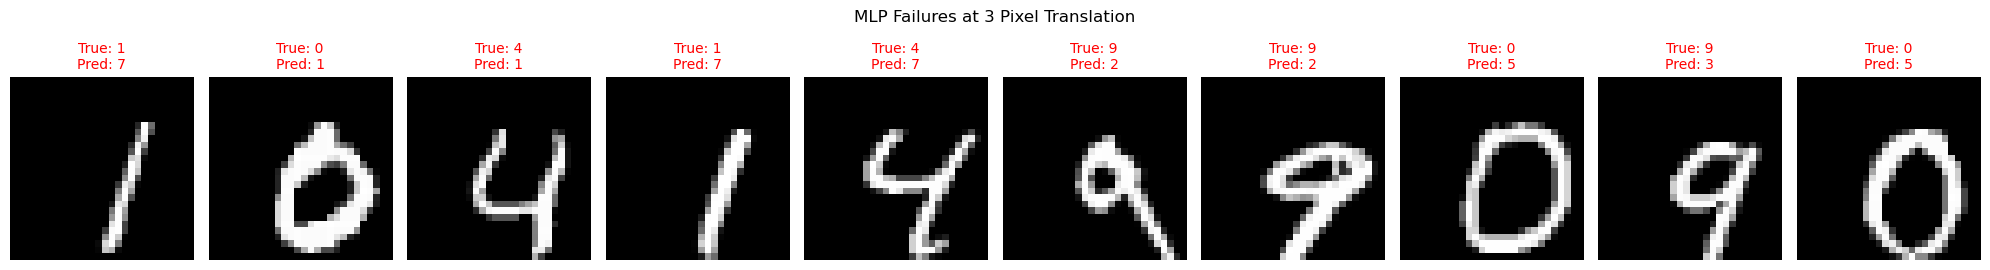

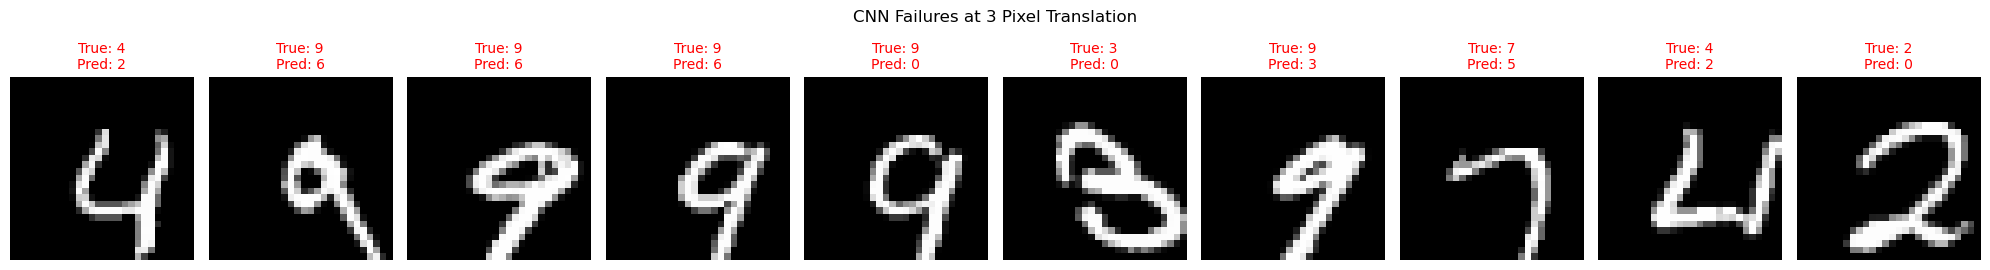

In [11]:
# Experiment 2: translation
translation = [(1, 1), (2, 2), (3, 3), (4, 4), (5, 5)]
mlp_trans_accs, cnn_trans_accs = [], []

for shift in translation:
    print(f'Evaluating translation = {shift} pixels...')
    perturbed = perturb_translation(test_images, shift)

    mlp_acc, mlp_pc, mlp_pr, mlp_tr = evaluate_on_perturbed(mlp_model, perturbed, test_labels)
    cnn_acc, cnn_pc, cnn_pr, cnn_tr = evaluate_on_perturbed(cnn_model, perturbed, test_labels)  

    mlp_trans_accs.append(mlp_acc)
    cnn_trans_accs.append(cnn_acc)

    results.loc[len(results)] = ['translation', shift[0], mlp_acc, cnn_acc, cnn_acc - mlp_acc]
    print(f'  MLP: {mlp_acc:.2f}%  |  CNN: {cnn_acc:.2f}%')

plot_degradation_curve([s[0] for s in translation], mlp_trans_accs, cnn_trans_accs,
                       xlabel='Translation Shift (pixels)',
                       title='Robustness to Translation: MLP vs. CNN')  

translation_3 = perturb_translation(test_images, (3, 3))
_, mlp_pc_3, mlp_pr_3, mlp_tr_3 = evaluate_on_perturbed(mlp_model, translation_3, test_labels)
_, cnn_pc_3, cnn_pr_3, cnn_tr_3 = evaluate_on_perturbed(cnn_model, translation_3, test_labels)
plot_per_class_comparison(mlp_pc_3, cnn_pc_3, title='Per-Class Accuracy at 3 Pixel Translation')

show_failure_examples(translation_3.numpy(), mlp_tr_3, mlp_pr_3, 'MLP',
                      title='MLP Failures at 3 Pixel Translation')
show_failure_examples(translation_3.numpy(), cnn_tr_3, cnn_pr_3, 'CNN',
                      title='CNN Failures at 3 Pixel Translation')

---

## 12. Experiment 3: Noise

Gaussian noise tests robustness to pixel-level corruption while preserving the overall digit structure.

Evaluating noise = 0.1...
  MLP: 97.92%  |  CNN: 99.01%
Evaluating noise = 0.2...
  MLP: 97.25%  |  CNN: 98.65%
Evaluating noise = 0.3...
  MLP: 94.14%  |  CNN: 96.46%
Evaluating noise = 0.4...
  MLP: 86.81%  |  CNN: 87.40%
Evaluating noise = 0.5...
  MLP: 74.41%  |  CNN: 71.32%
Evaluating noise = 0.6...
  MLP: 60.26%  |  CNN: 55.66%
Evaluating noise = 0.7...
  MLP: 49.10%  |  CNN: 44.64%
Evaluating noise = 0.8...
  MLP: 40.67%  |  CNN: 35.67%
Evaluating noise = 0.9...
  MLP: 34.22%  |  CNN: 30.07%
Evaluating noise = 1.0...
  MLP: 29.56%  |  CNN: 26.30%


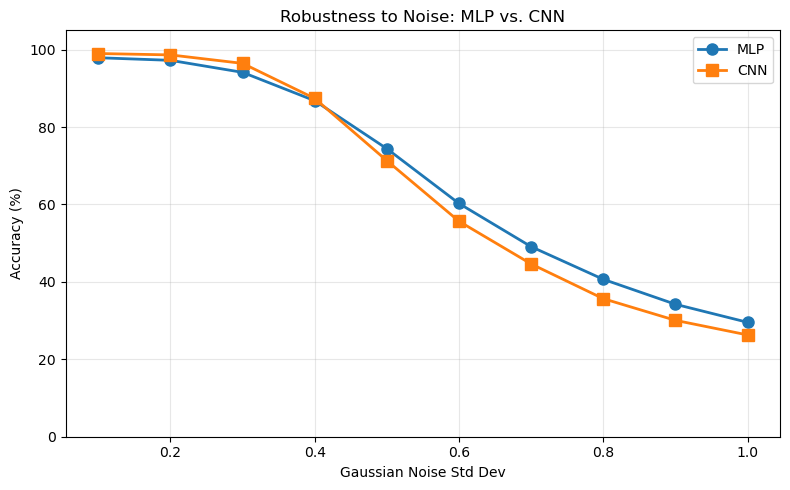

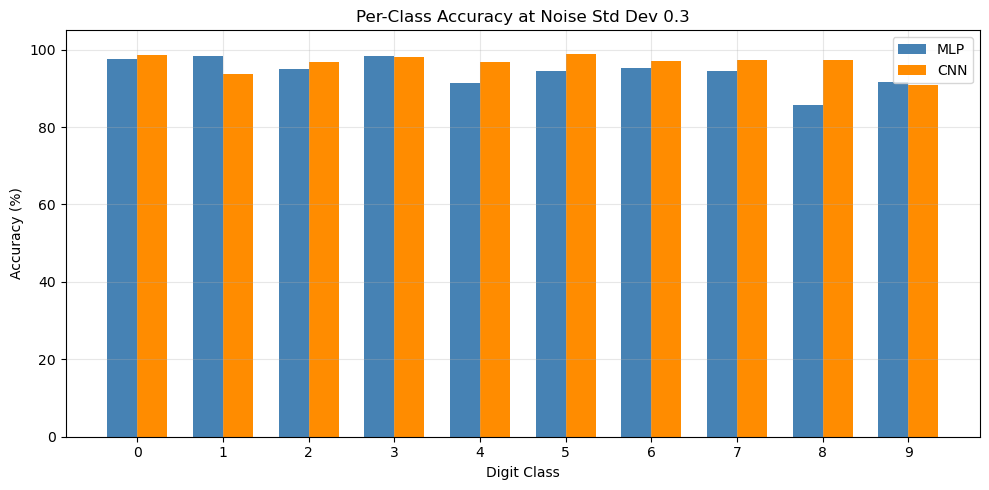

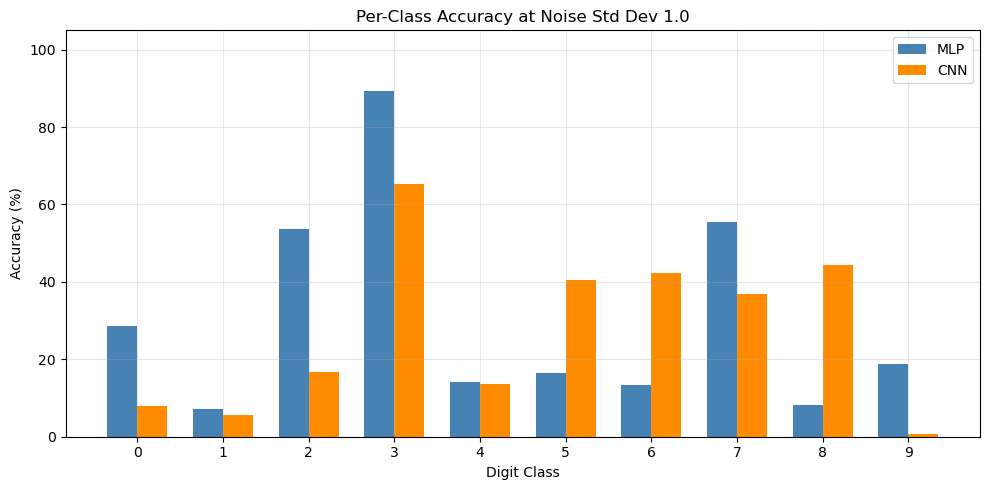

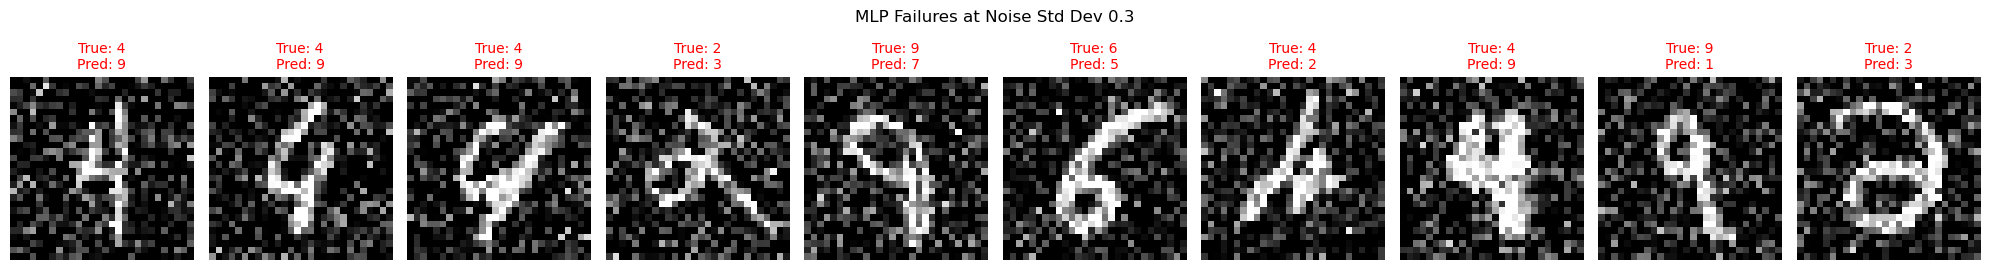

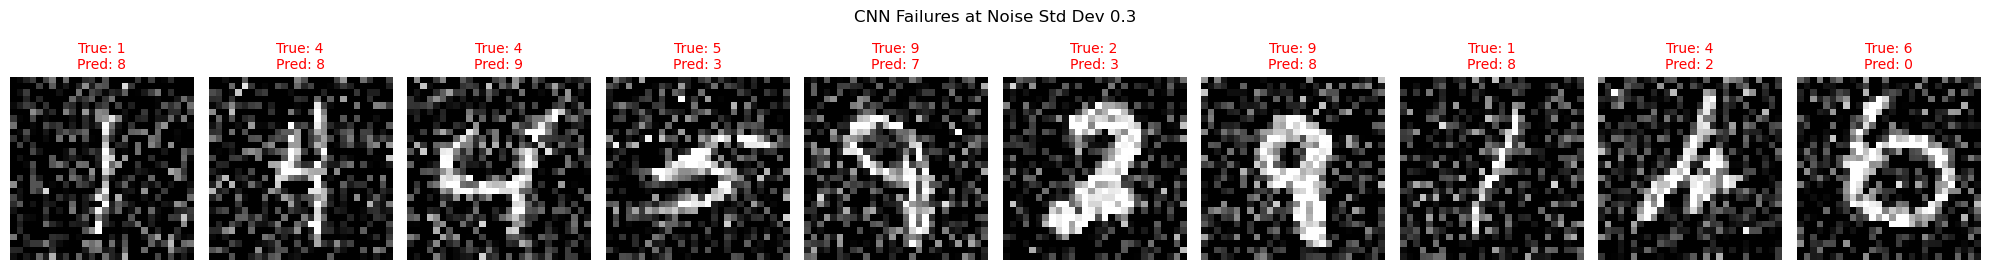

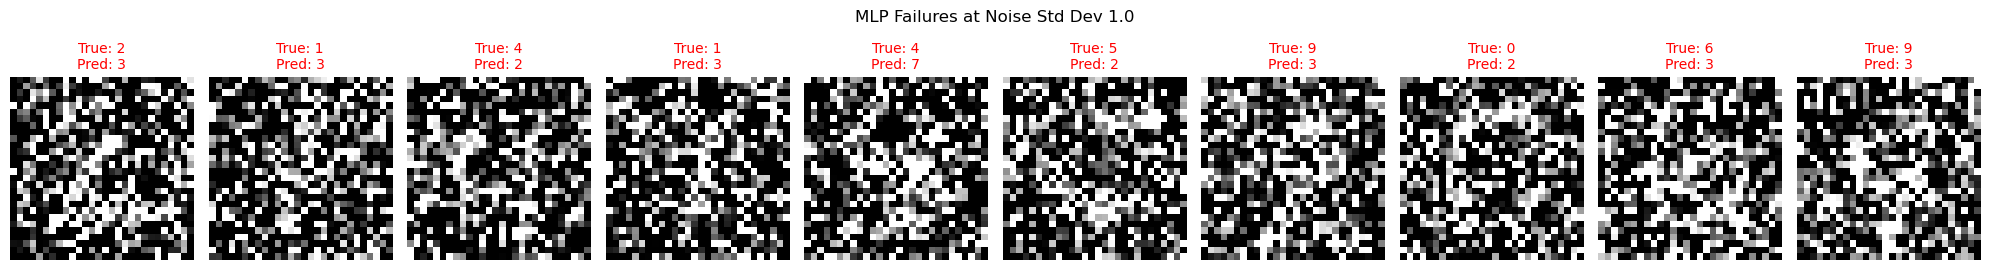

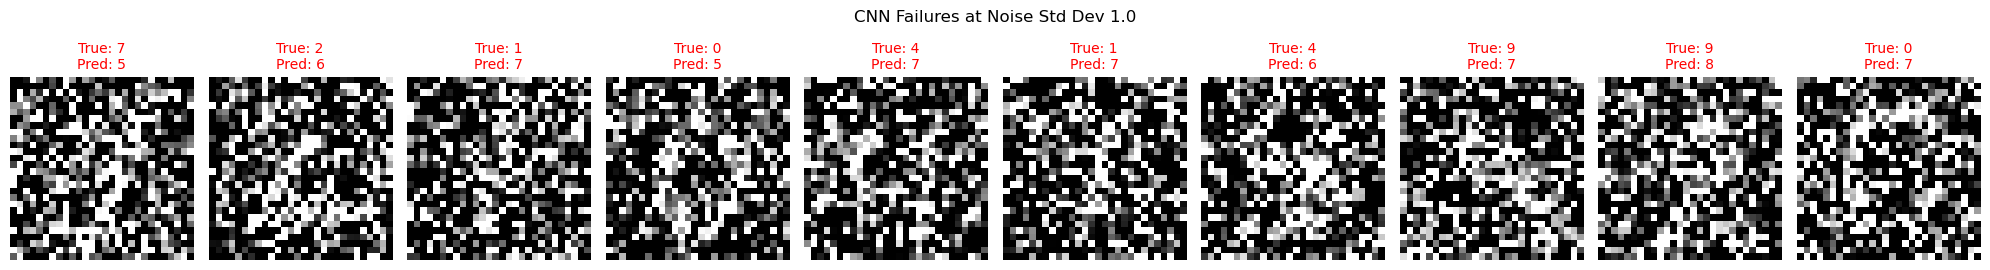

In [12]:
# Experiment 3: Gaussian noise
noise=[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
mlp_noise_accs, cnn_noise_accs = [], []

for noise_std in noise:
    print(f'Evaluating noise = {noise_std}...')
    perturbed = perturb_noise(test_images, noise_std)

    mlp_acc, mlp_pc, mlp_pr, mlp_tr = evaluate_on_perturbed(mlp_model, perturbed, test_labels)
    cnn_acc, cnn_pc, cnn_pr, cnn_tr = evaluate_on_perturbed(cnn_model, perturbed, test_labels)  

    mlp_noise_accs.append(mlp_acc)
    cnn_noise_accs.append(cnn_acc)

    results.loc[len(results)] = ['noise', noise_std, mlp_acc, cnn_acc, cnn_acc - mlp_acc]
    print(f'  MLP: {mlp_acc:.2f}%  |  CNN: {cnn_acc:.2f}%')

plot_degradation_curve(noise, mlp_noise_accs, cnn_noise_accs,
                       xlabel='Gaussian Noise Std Dev',
                       title='Robustness to Noise: MLP vs. CNN')

noise_0_3 = perturb_noise(test_images, 0.3)
_, mlp_pc_0_3, mlp_pr_0_3, mlp_tr_0_3 = evaluate_on_perturbed(mlp_model, noise_0_3, test_labels)
_, cnn_pc_0_3, cnn_pr_0_3, cnn_tr_0_3 = evaluate_on_perturbed(cnn_model, noise_0_3, test_labels)
plot_per_class_comparison(mlp_pc_0_3, cnn_pc_0_3, title='Per-Class Accuracy at Noise Std Dev 0.3')

noise_1_0 = perturb_noise(test_images, 1.0)
_, mlp_pc_1_0, mlp_pr_1_0, mlp_tr_1_0 = evaluate_on_perturbed(mlp_model, noise_1_0, test_labels)
_, cnn_pc_1_0, cnn_pr_1_0, cnn_tr_1_0 = evaluate_on_perturbed(cnn_model, noise_1_0, test_labels)
plot_per_class_comparison(mlp_pc_1_0, cnn_pc_1_0, title='Per-Class Accuracy at Noise Std Dev 1.0')

show_failure_examples(noise_0_3.numpy(), mlp_tr_0_3, mlp_pr_0_3, 'MLP',
                      title='MLP Failures at Noise Std Dev 0.3')
show_failure_examples(noise_0_3.numpy(), cnn_tr_0_3, cnn_pr_0_3, 'CNN',
                      title='CNN Failures at Noise Std Dev 0.3')

show_failure_examples(noise_1_0.numpy(), mlp_tr_1_0, mlp_pr_1_0, 'MLP',
                        title='MLP Failures at Noise Std Dev 1.0')
show_failure_examples(noise_1_0.numpy(), cnn_tr_1_0, cnn_pr_1_0, 'CNN',
                        title='CNN Failures at Noise Std Dev 1.0')

---

## 13. Experiment 4: Blur

Gaussian blur removes local edge detail and tests how much each model depends on crisp stroke boundaries.

Evaluating blur = 0.5...
  MLP: 98.08%  |  CNN: 99.06%
Evaluating blur = 1.0...
  MLP: 97.42%  |  CNN: 98.77%
Evaluating blur = 1.5...
  MLP: 92.16%  |  CNN: 96.99%
Evaluating blur = 2.0...
  MLP: 76.20%  |  CNN: 91.91%
Evaluating blur = 3.0...
  MLP: 41.36%  |  CNN: 56.70%
Evaluating blur = 4.0...
  MLP: 24.23%  |  CNN: 27.58%
Evaluating blur = 5.0...
  MLP: 14.74%  |  CNN: 17.10%


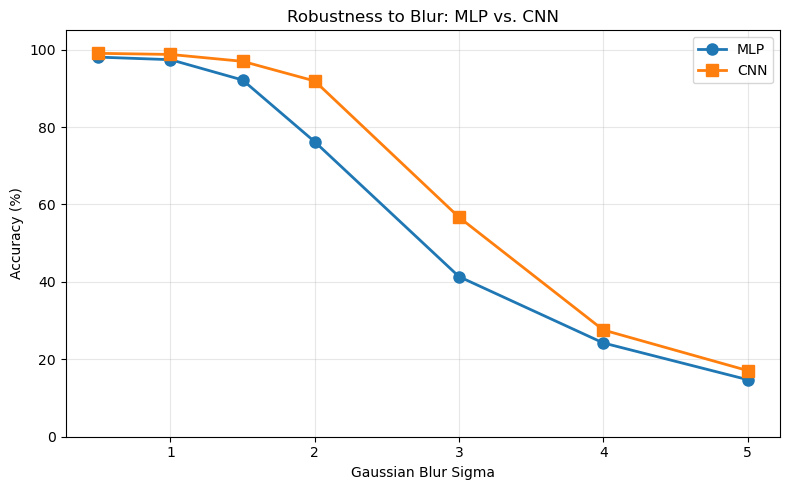

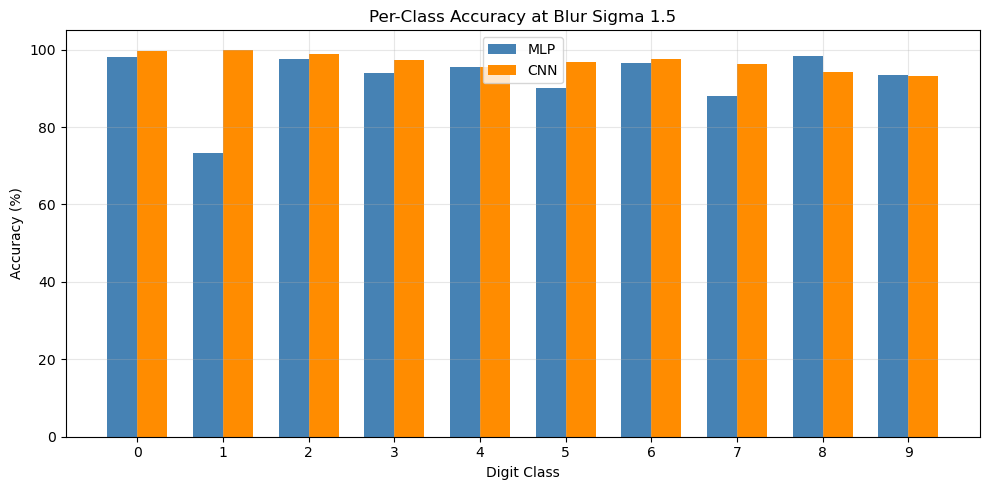

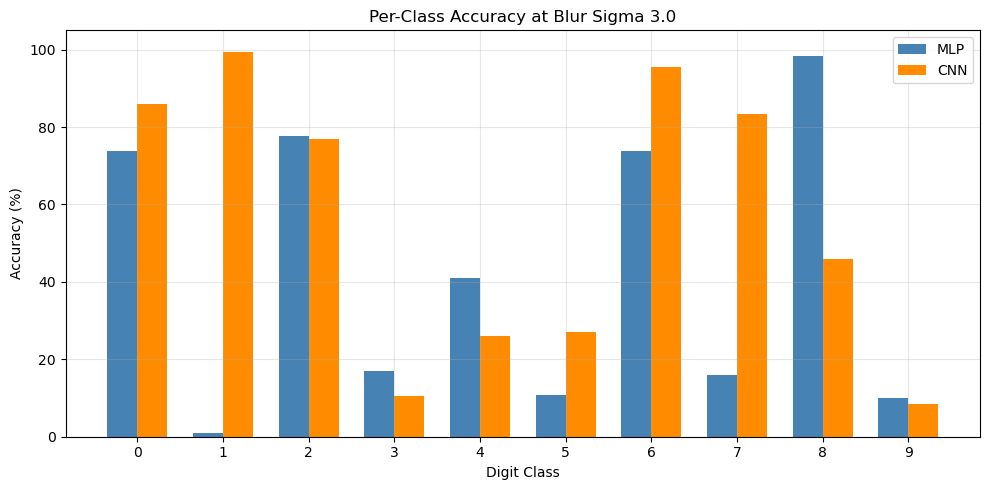

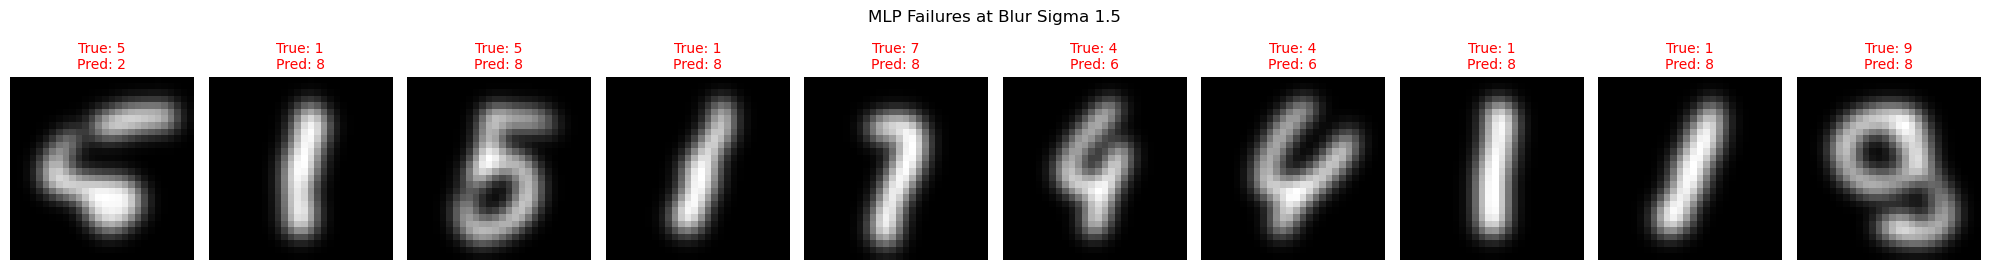

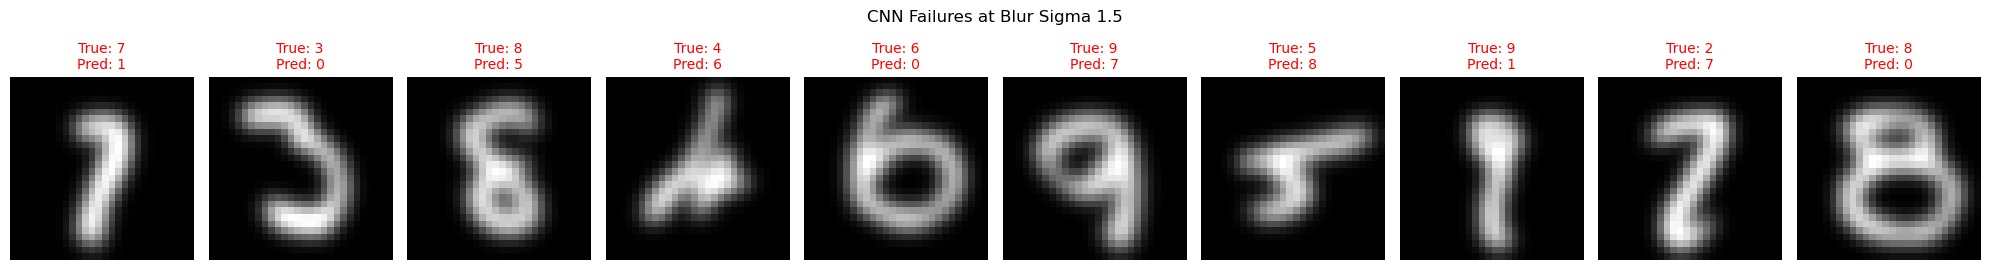

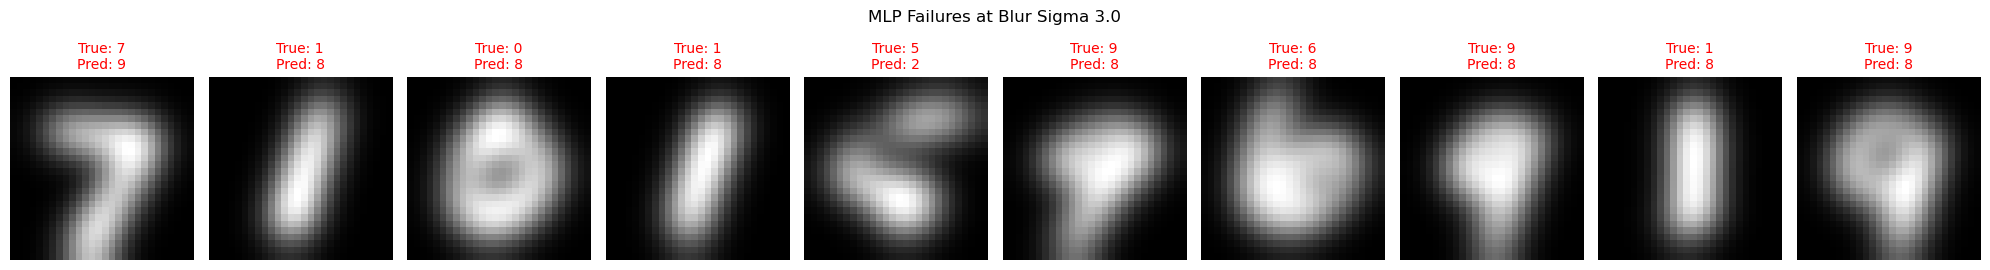

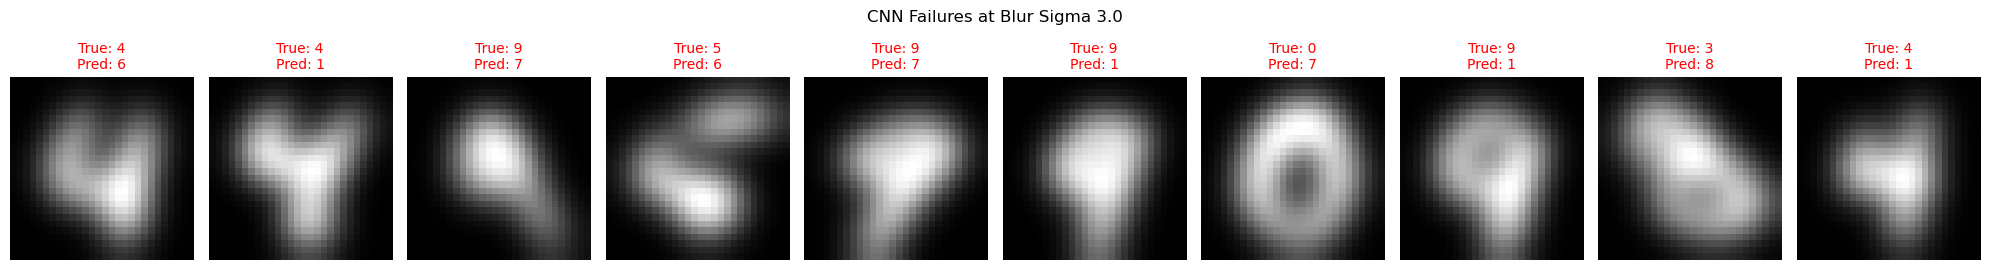

In [13]:
blur = [0.5, 1.0, 1.5, 2.0, 3.0, 4.0, 5.0]
mlp_blur_accs, cnn_blur_accs = [], []

for sigma in blur:
    print(f'Evaluating blur = {sigma}...')
    perturbed = perturb_blur(test_images, sigma)

    mlp_acc, mlp_pc, mlp_pr, mlp_tr = evaluate_on_perturbed(mlp_model, perturbed, test_labels)
    cnn_acc, cnn_pc, cnn_pr, cnn_tr = evaluate_on_perturbed(cnn_model, perturbed, test_labels)  

    mlp_blur_accs.append(mlp_acc)
    cnn_blur_accs.append(cnn_acc)

    results.loc[len(results)] = ['blur', sigma, mlp_acc, cnn_acc, cnn_acc - mlp_acc]
    print(f'  MLP: {mlp_acc:.2f}%  |  CNN: {cnn_acc:.2f}%')

plot_degradation_curve(blur, mlp_blur_accs, cnn_blur_accs,
                       xlabel='Gaussian Blur Sigma',
                          title='Robustness to Blur: MLP vs. CNN') 

blur_1_5 = perturb_blur(test_images, 1.5)
_, mlp_pc_1_5, mlp_pr_1_5, mlp_tr_1_5 = evaluate_on_perturbed(mlp_model, blur_1_5, test_labels)
_, cnn_pc_1_5, cnn_pr_1_5, cnn_tr_1_5 = evaluate_on_perturbed(cnn_model, blur_1_5, test_labels)
plot_per_class_comparison(mlp_pc_1_5, cnn_pc_1_5, title='Per-Class Accuracy at Blur Sigma 1.5')

blur_3_0 = perturb_blur(test_images, 3.0)
_, mlp_pc_3_0, mlp_pr_3_0, mlp_tr_3_0 = evaluate_on_perturbed(mlp_model, blur_3_0, test_labels)
_, cnn_pc_3_0, cnn_pr_3_0, cnn_tr_3_0 = evaluate_on_perturbed(cnn_model, blur_3_0, test_labels)
plot_per_class_comparison(mlp_pc_3_0, cnn_pc_3_0, title='Per-Class Accuracy at Blur Sigma 3.0')

show_failure_examples(blur_1_5.numpy(), mlp_tr_1_5, mlp_pr_1_5, 'MLP',
                      title='MLP Failures at Blur Sigma 1.5')   
show_failure_examples(blur_1_5.numpy(), cnn_tr_1_5, cnn_pr_1_5, 'CNN',
                      title='CNN Failures at Blur Sigma 1.5')

show_failure_examples(blur_3_0.numpy(), mlp_tr_3_0, mlp_pr_3_0, 'MLP',
                      title='MLP Failures at Blur Sigma 3.0')
show_failure_examples(blur_3_0.numpy(), cnn_tr_3_0, cnn_pr_3_0, 'CNN',
                      title='CNN Failures at Blur Sigma 3.0')

---

## 14. Experiment 5: Erosion

Evaluating erosion = 0.1 iterations...
  MLP: 97.94%  |  CNN: 99.08%
Evaluating erosion = 0.3 iterations...
  MLP: 97.63%  |  CNN: 99.04%
Evaluating erosion = 0.5 iterations...
  MLP: 96.11%  |  CNN: 98.75%
Evaluating erosion = 0.7 iterations...
  MLP: 85.83%  |  CNN: 95.99%
Evaluating erosion = 0.8 iterations...
  MLP: 72.46%  |  CNN: 87.55%
Evaluating erosion = 0.9 iterations...
  MLP: 55.03%  |  CNN: 69.19%
Evaluating erosion = 1.0 iterations...
  MLP: 39.36%  |  CNN: 54.94%
Evaluating erosion = 2.0 iterations...
  MLP: 9.90%  |  CNN: 13.39%
Evaluating erosion = 3.0 iterations...
  MLP: 8.93%  |  CNN: 11.46%


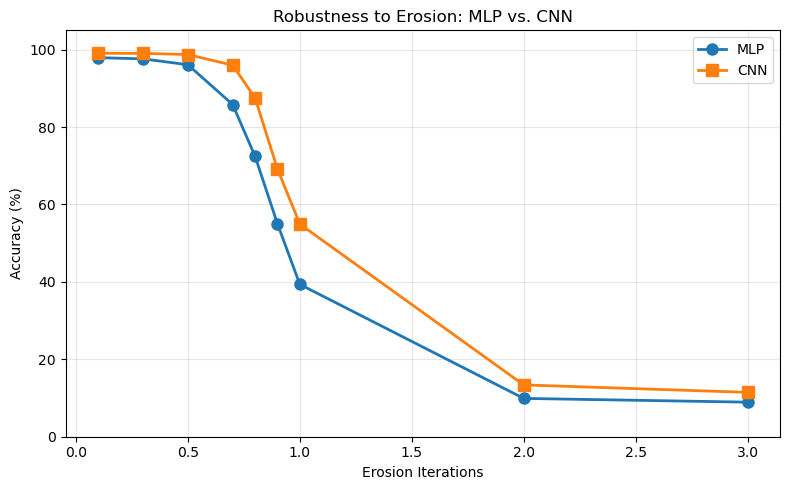

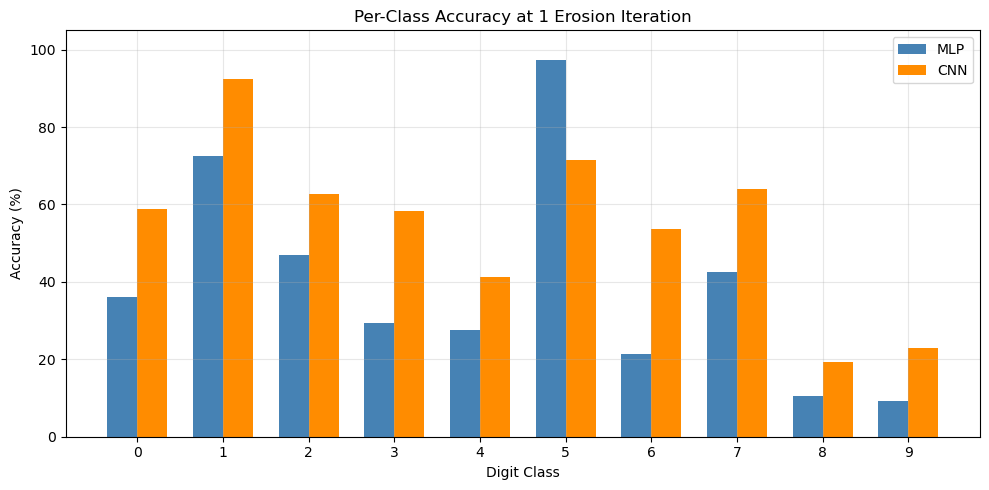

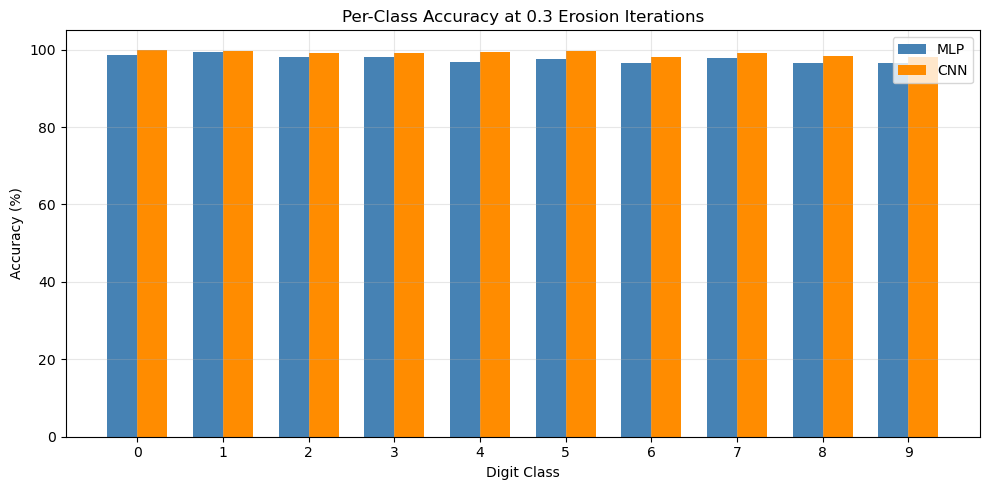

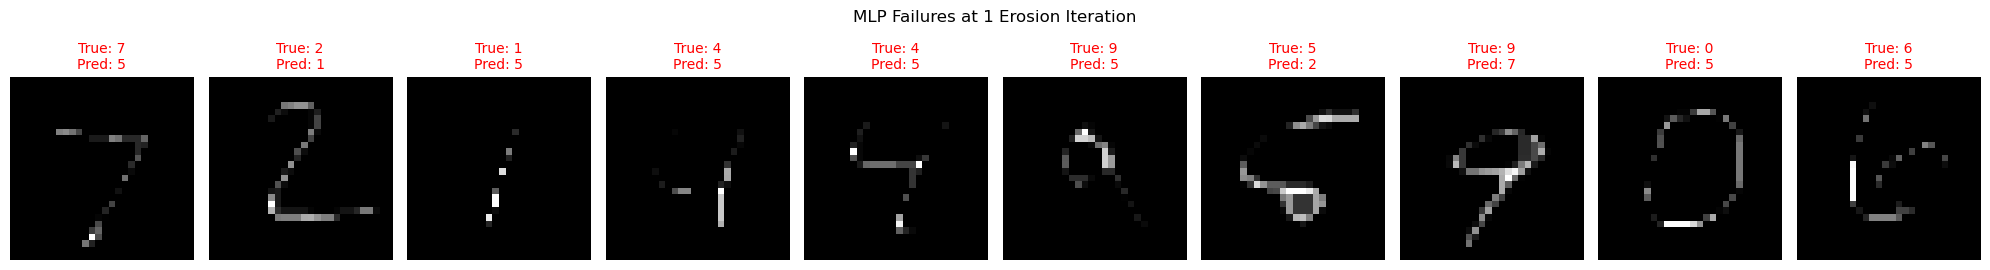

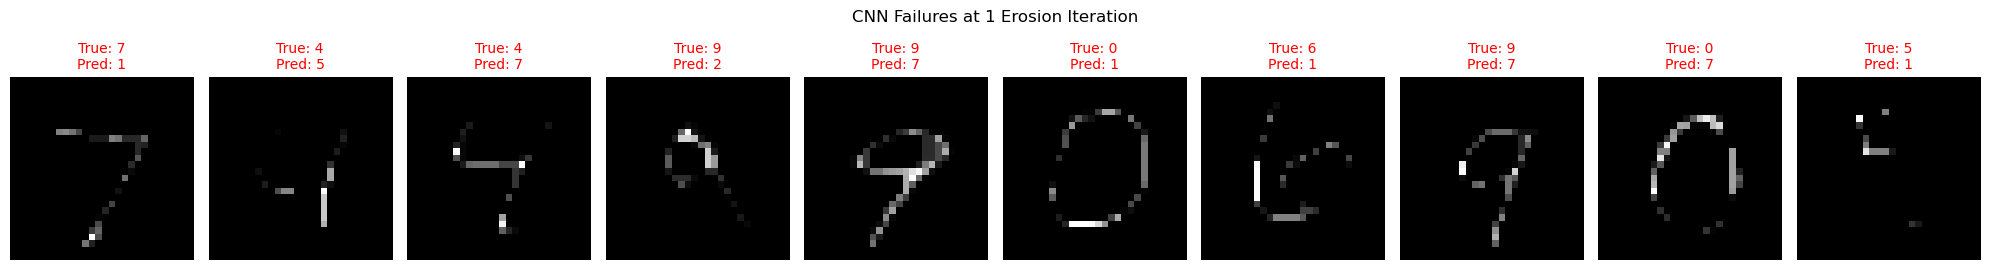

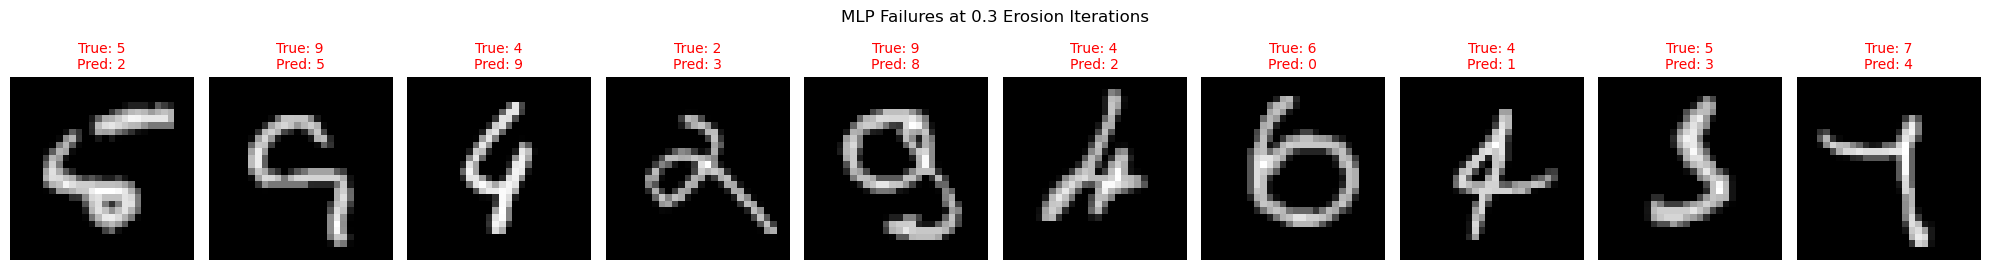

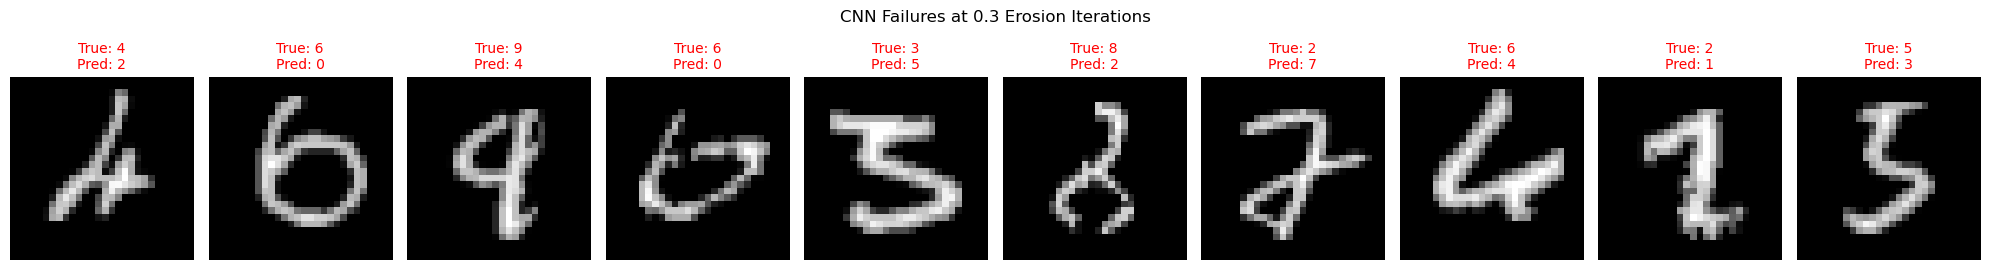

In [14]:
erosion = [0.1, 0.3, 0.5, 0.7, 0.8, 0.9, 1.0, 2.0, 3.0]
mlp_erosion_accs, cnn_erosion_accs = [], []

for iter in erosion:
    print(f'Evaluating erosion = {iter} iterations...')
    perturbed = perturb_erosion(test_images, iter)

    mlp_acc, mlp_pc, mlp_pr, mlp_tr = evaluate_on_perturbed(mlp_model, perturbed, test_labels)
    cnn_acc, cnn_pc, cnn_pr, cnn_tr = evaluate_on_perturbed(cnn_model, perturbed, test_labels)  

    mlp_erosion_accs.append(mlp_acc)
    cnn_erosion_accs.append(cnn_acc)

    results.loc[len(results)] = ['erosion', iter, mlp_acc, cnn_acc, cnn_acc - mlp_acc]
    print(f'  MLP: {mlp_acc:.2f}%  |  CNN: {cnn_acc:.2f}%')

plot_degradation_curve(erosion, mlp_erosion_accs, cnn_erosion_accs,
                       xlabel='Erosion Iterations',
                       title='Robustness to Erosion: MLP vs. CNN') 
erosion_1 = perturb_erosion(test_images, 1.0)
_, mlp_pc_1e, mlp_pr_1e, mlp_tr_1e = evaluate_on_perturbed(mlp_model, erosion_1, test_labels)
_, cnn_pc_1e, cnn_pr_1e, cnn_tr_1e = evaluate_on_perturbed(cnn_model, erosion_1, test_labels)
plot_per_class_comparison(mlp_pc_1e, cnn_pc_1e, title='Per-Class Accuracy at 1 Erosion Iteration')

erosion_0_3 = perturb_erosion(test_images, 0.3)
_, mlp_pc_0_3e, mlp_pr_0_3e, mlp_tr_0_3e = evaluate_on_perturbed(mlp_model, erosion_0_3, test_labels)
_, cnn_pc_0_3e, cnn_pr_0_3e, cnn_tr_0_3e = evaluate_on_perturbed(cnn_model, erosion_0_3, test_labels)
plot_per_class_comparison(mlp_pc_0_3e, cnn_pc_0_3e, title='Per-Class Accuracy at 0.3 Erosion Iterations')

show_failure_examples(erosion_1.numpy(), mlp_tr_1e, mlp_pr_1e, 'MLP',
                      title='MLP Failures at 1 Erosion Iteration')

show_failure_examples(erosion_1.numpy(), cnn_tr_1e, cnn_pr_1e, 'CNN',
                      title='CNN Failures at 1 Erosion Iteration')

show_failure_examples(erosion_0_3.numpy(), mlp_tr_0_3e, mlp_pr_0_3e, 'MLP',
                      title='MLP Failures at 0.3 Erosion Iterations')       
show_failure_examples(erosion_0_3.numpy(), cnn_tr_0_3e, cnn_pr_0_3e, 'CNN',
                      title='CNN Failures at 0.3 Erosion Iterations')


---

## 15. Experiment 6: Inversion

  MLP: 1.23%  |  CNN: 31.05%


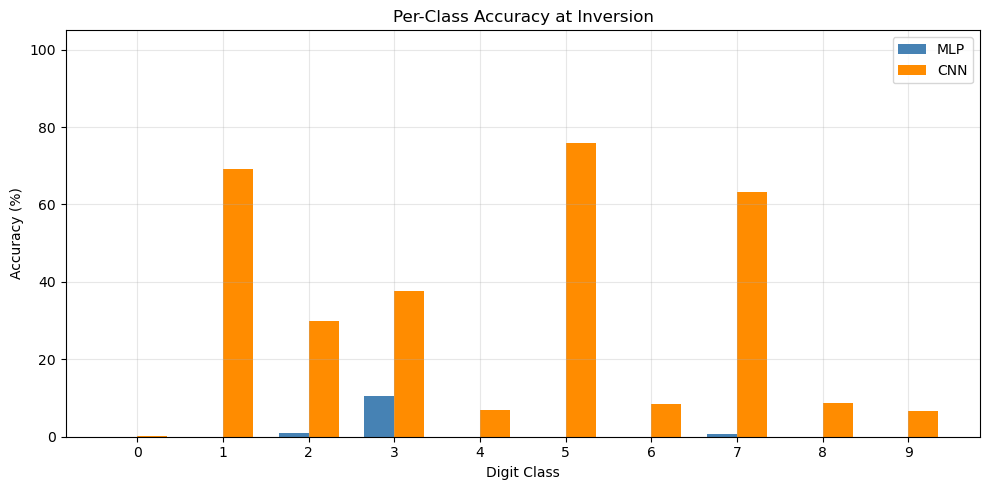

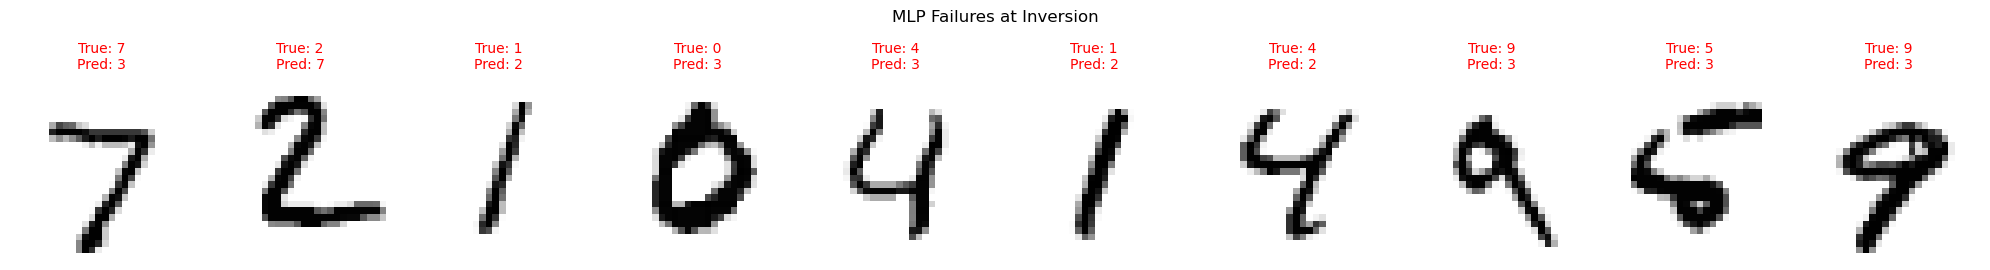

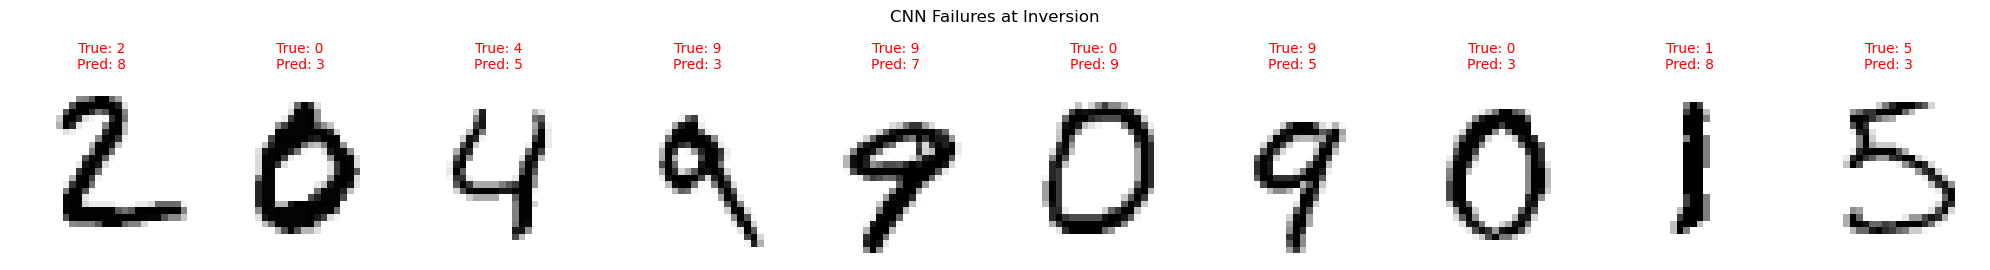

In [15]:
inversion = perturb_inversion(test_images)

mlp_acc_inv, mlp_pc_inv, mlp_pr_inv, mlp_tr_inv = evaluate_on_perturbed(mlp_model, inversion, test_labels)
cnn_acc_inv, cnn_pc_inv, cnn_pr_inv, cnn_tr_inv = evaluate_on_perturbed(cnn_model, inversion, test_labels)

results.loc[len(results)] = ['inversion', 0, mlp_acc_inv, cnn_acc_inv, cnn_acc_inv - mlp_acc_inv]
print(f'  MLP: {mlp_acc_inv:.2f}%  |  CNN: {cnn_acc_inv:.2f}%')

plot_per_class_comparison(mlp_pc_inv, cnn_pc_inv, title='Per-Class Accuracy at Inversion')
show_failure_examples(inversion.numpy(), mlp_tr_inv, mlp_pr_inv, 'MLP',
                      title='MLP Failures at Inversion')    
show_failure_examples(inversion.numpy(), cnn_tr_inv, cnn_pr_inv, 'CNN',
                      title='CNN Failures at Inversion')    

---

## 16. Experiment 7 : Hand drawn images

Loaded 10 hand-drawn images from hand_drawn_numbers.


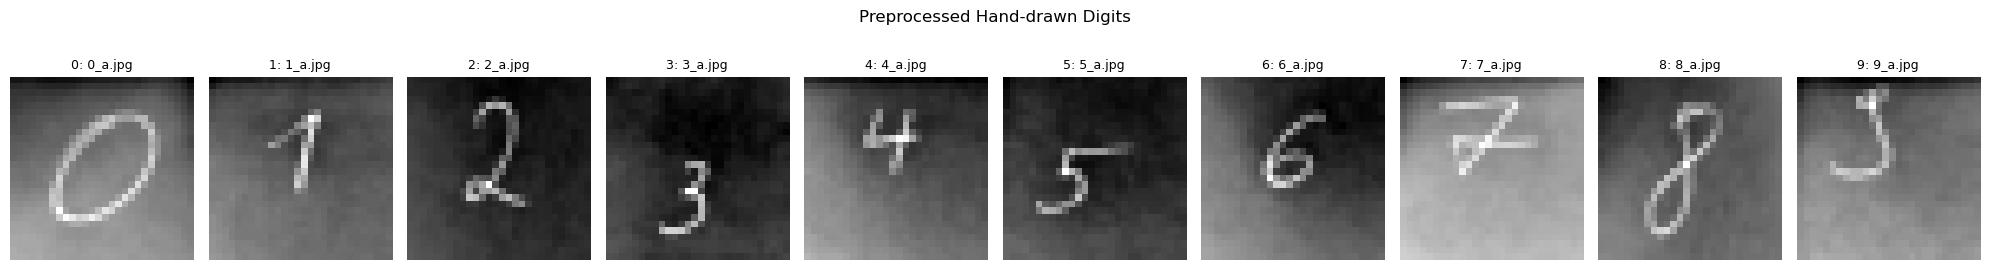

Hand-drawn MLP Accuracy: 10.00%
Hand-drawn CNN Accuracy: 20.00%


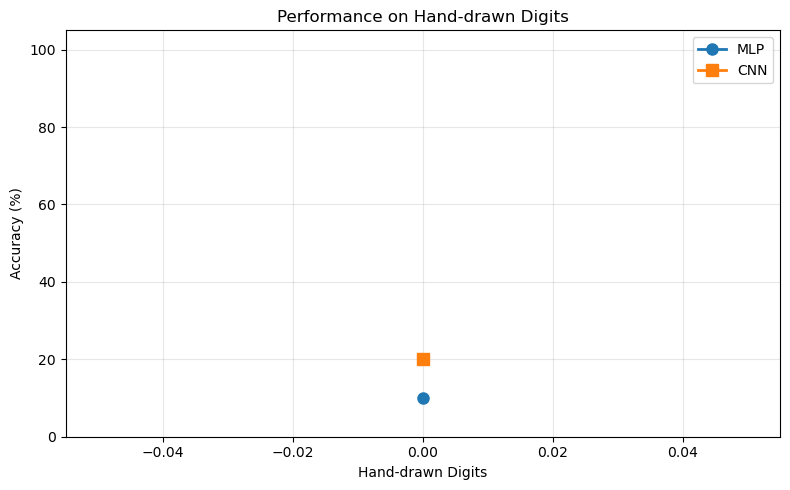

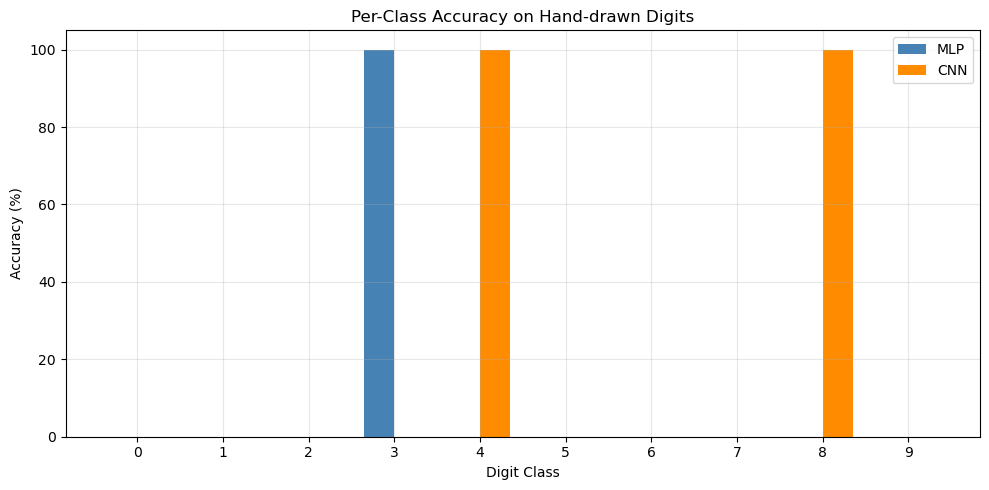

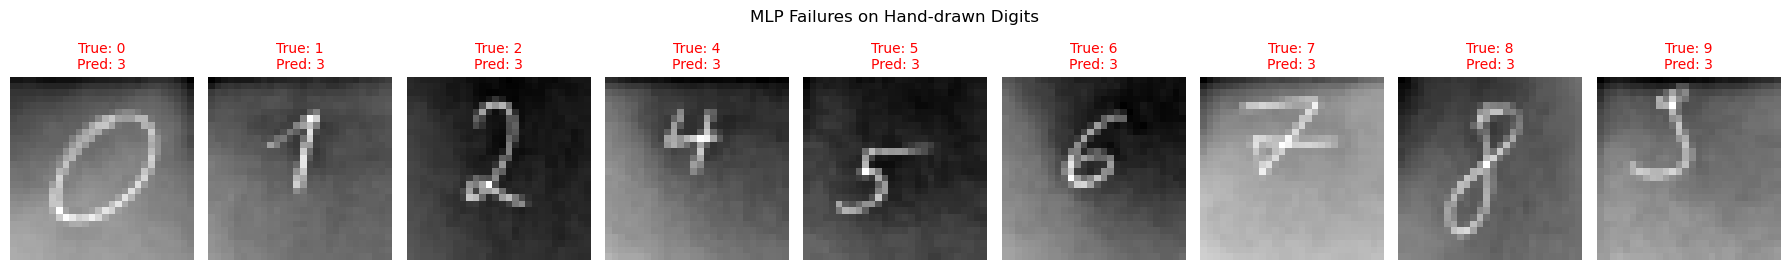

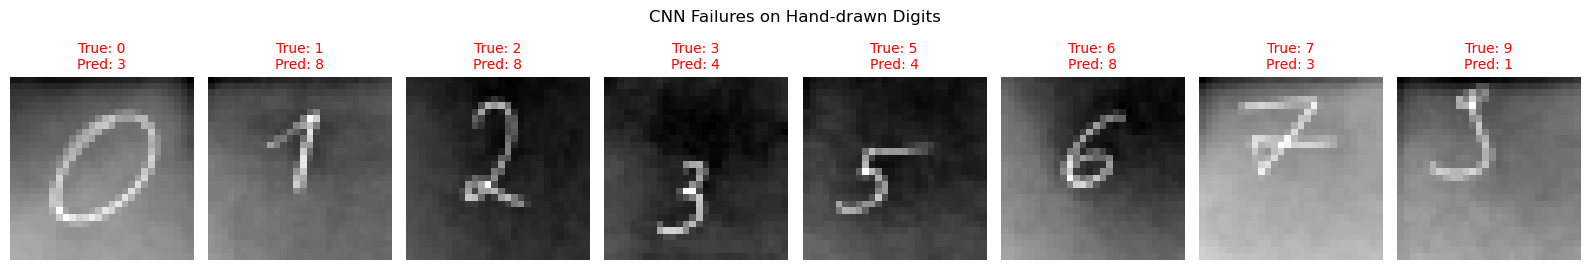

Top MLP Confusions on Hand-drawn Digits
  true 0 -> pred 3: 1 samples (100.00% of class 0)
  true 1 -> pred 3: 1 samples (100.00% of class 1)
  true 2 -> pred 3: 1 samples (100.00% of class 2)
  true 4 -> pred 3: 1 samples (100.00% of class 4)
  true 5 -> pred 3: 1 samples (100.00% of class 5)
Top CNN Confusions on Hand-drawn Digits
  true 0 -> pred 3: 1 samples (100.00% of class 0)
  true 1 -> pred 8: 1 samples (100.00% of class 1)
  true 2 -> pred 8: 1 samples (100.00% of class 2)
  true 3 -> pred 4: 1 samples (100.00% of class 3)
  true 5 -> pred 4: 1 samples (100.00% of class 5)


In [16]:
# Experiment 7: creative hand-drawn digits with simple MNIST-style preprocessing.
# Reuse the existing torch/torchvision workflow and the shared evaluation helpers.

def resolve_handdrawn_folder():
    """Resolve the hand-drawn digit folder from common notebook working directories."""
    candidates = [
        'hand_drawn_numbers',
        os.path.join('RQ2 (Woche4)', 'hand_drawn_numbers')
    ]
    for folder in candidates:
        if os.path.isdir(folder):
            return folder
    raise FileNotFoundError('Could not find the hand_drawn_numbers folder.')


def preprocess_handdrawn_image(image_path, output_size=28):
    """Load one hand-drawn image and convert it into a 28x28 MNIST-like tensor in [0, 1]."""
    img = Image.open(image_path).convert('L')
    img_tensor = TF.to_tensor(img)
    img_tensor = TF.resize(img_tensor, [output_size, output_size])

    # Blue pen on white paper -> invert so the result matches MNIST.
    img_tensor = perturb_inversion(img_tensor)

    return img_tensor.squeeze(0)


def load_handdrawn_images(folder_path):
    """Load hand-drawn digit images from a folder.
    Expected: files named like '0_a.png', '3_b.jpg' (digit_id.ext)."""
    images, labels, names = [], [], []
    for fname in sorted(os.listdir(folder_path)):
        if not fname.lower().endswith(('.png', '.jpg', '.jpeg')):
            continue
        label = int(fname.split('_')[0])
        processed = preprocess_handdrawn_image(os.path.join(folder_path, fname))
        images.append(processed)
        labels.append(label)
        names.append(fname)

    if not images:
        raise ValueError('No hand-drawn images found in the selected folder.')

    image_tensor = torch.stack(images).float()
    label_tensor = torch.tensor(labels, dtype=torch.long)
    return image_tensor, label_tensor, names


def preview_handdrawn_samples(images, labels, names, title='Preprocessed Hand-drawn Digits', max_samples=10):
    """Preview the preprocessed hand-drawn images to verify alignment with MNIST."""
    n_samples = min(len(images), max_samples)
    fig, axes = plt.subplots(1, n_samples, figsize=(2 * n_samples, 3))
    if n_samples == 1:
        axes = [axes]
    for ax, image, label, name in zip(axes, images[:n_samples], labels[:n_samples], names[:n_samples]):
        ax.imshow(image, cmap='gray')
        ax.set_title(f'{label}: {name}', fontsize=9)
        ax.axis('off')
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


hand_drawn_folder = resolve_handdrawn_folder()
hand_images, hand_labels, hand_names = load_handdrawn_images(hand_drawn_folder)
print(f'Loaded {len(hand_images)} hand-drawn images from {hand_drawn_folder}.')
preview_handdrawn_samples(hand_images.numpy(), hand_labels.tolist(), hand_names)

mlp_acc_hand, mlp_pc_hand, mlp_pr_hand, mlp_tr_hand = evaluate_on_perturbed(mlp_model, hand_images, hand_labels)
cnn_acc_hand, cnn_pc_hand, cnn_pr_hand, cnn_tr_hand = evaluate_on_perturbed(cnn_model, hand_images, hand_labels)

results.loc[len(results)] = ['hand-drawn', 0, mlp_acc_hand, cnn_acc_hand, cnn_acc_hand - mlp_acc_hand]
print(f'Hand-drawn MLP Accuracy: {mlp_acc_hand:.2f}%')
print(f'Hand-drawn CNN Accuracy: {cnn_acc_hand:.2f}%')

plot_degradation_curve([0], [mlp_acc_hand], [cnn_acc_hand],
                       xlabel='Hand-drawn Digits', title='Performance on Hand-drawn Digits')
plot_per_class_comparison(mlp_pc_hand, cnn_pc_hand, title='Per-Class Accuracy on Hand-drawn Digits')
show_failure_examples(hand_images.numpy(), mlp_tr_hand, mlp_pr_hand, 'MLP', title='MLP Failures on Hand-drawn Digits')
show_failure_examples(hand_images.numpy(), cnn_tr_hand, cnn_pr_hand, 'CNN', title='CNN Failures on Hand-drawn Digits')
print_top_confusions(mlp_tr_hand, mlp_pr_hand, title='Top MLP Confusions on Hand-drawn Digits')
print_top_confusions(cnn_tr_hand, cnn_pr_hand, title='Top CNN Confusions on Hand-drawn Digits')



---

## 17. Confusion Matrix Analysis

For at least **2 interesting perturbation types**, plot confusion matrices.  
Look for systematic misclassification patterns (e.g., rotated 6 → predicted as 9).


MLP -- strongest confusions for rotation
perturbation  intensity  accuracy  true_digit  pred_digit  confusion_count  true_total  rate_within_true_class
    rotation        180     30.91           9           6              883        1009               87.512389
    rotation        180     30.91           7           6              824        1028               80.155642
    rotation         90     10.73           1           7              903        1135               79.559471
    rotation        180     30.91           6           9              608         958               63.465553
    rotation        180     30.91           3           8              604        1010               59.801980
    rotation         90     10.73           9           5              484        1009               47.968285
    rotation        180     30.91           4           6              461         982               46.945010
    rotation         45     49.77           7           9             

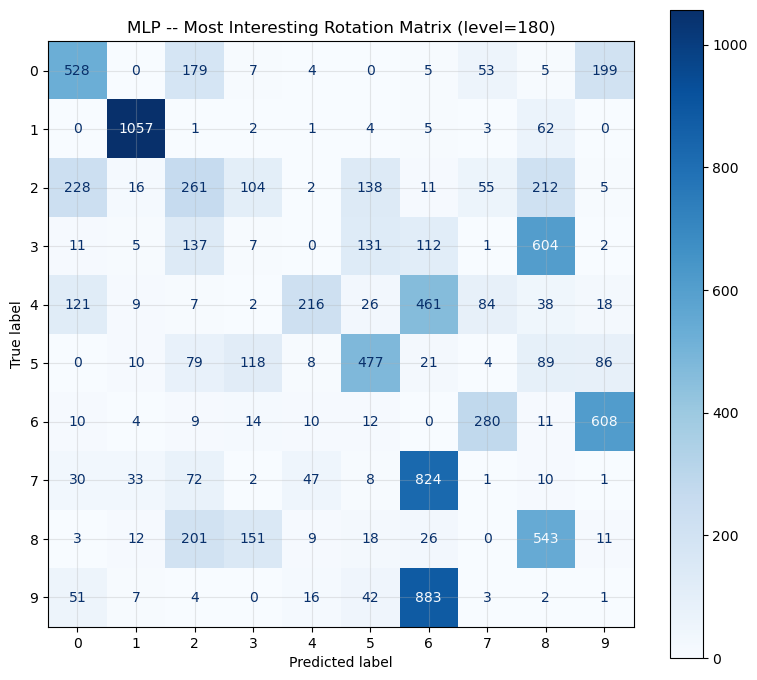


CNN -- strongest confusions for rotation
perturbation  intensity  accuracy  true_digit  pred_digit  confusion_count  true_total  rate_within_true_class
    rotation        180     37.06           9           6              860        1009               85.232904
    rotation         90     16.48           1           7              912        1135               80.352423
    rotation        180     37.06           6           9              724         958               75.574113
    rotation        180     37.06           7           6              709        1028               68.968872
    rotation        180     37.06           3           8              672        1010               66.534653
    rotation         90     16.48           7           0              632        1028               61.478599
    rotation         90     16.48           3           0              559        1010               55.346535
    rotation         90     16.48           4           7             

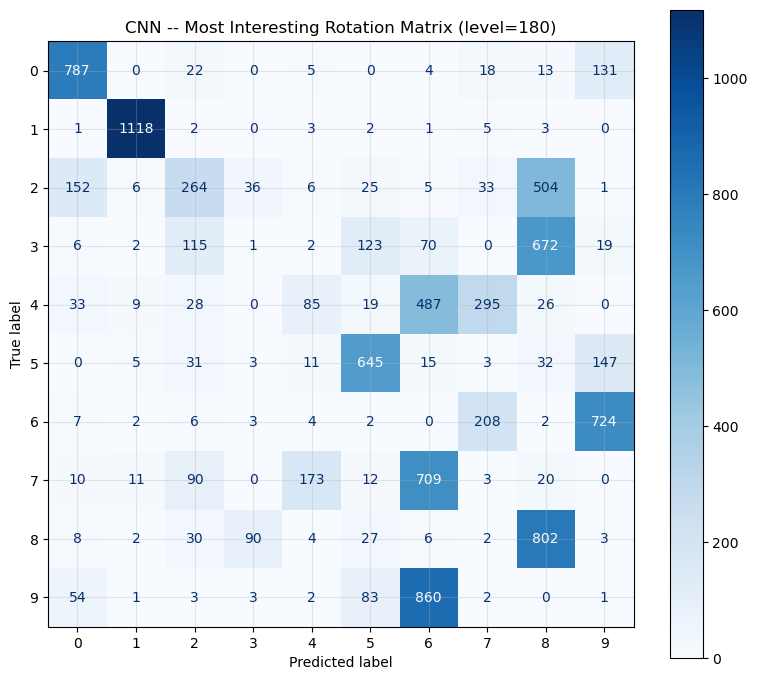


MLP -- strongest confusions for translation
perturbation  intensity  accuracy  true_digit  pred_digit  confusion_count  true_total  rate_within_true_class
 translation          5      3.25           9           2              923        1009               91.476710
 translation          5      3.25           4           2              871         982               88.696538
 translation          4      6.16           4           2              864         982               87.983707
 translation          4      6.16           1           7              988        1135               87.048458
 translation          3     21.27           1           7              938        1135               82.643172
 translation          4      6.16           9           2              707        1009               70.069376
 translation          5      3.25           6           2              660         958               68.893528
 translation          4      6.16           6           2          

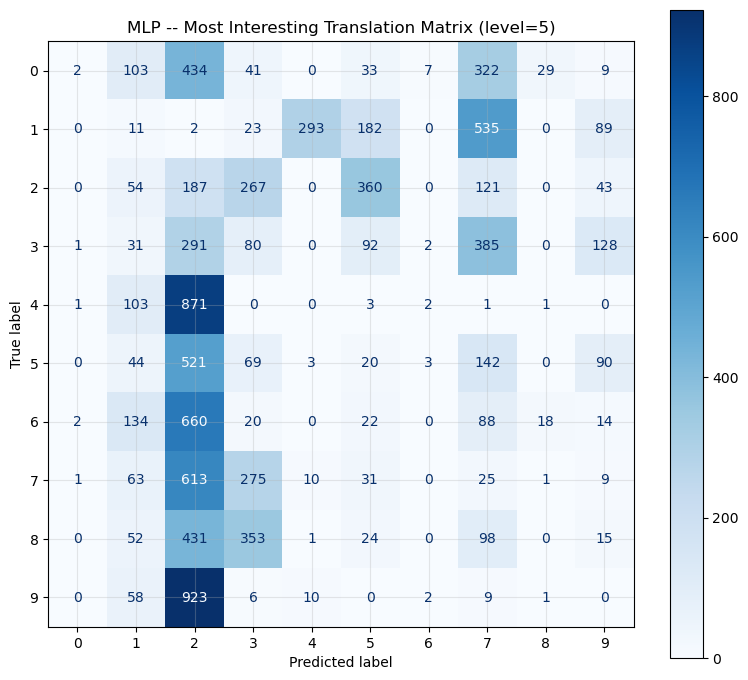


CNN -- strongest confusions for translation
perturbation  intensity  accuracy  true_digit  pred_digit  confusion_count  true_total  rate_within_true_class
 translation          5     12.81           9           6              910        1009               90.188305
 translation          4     39.17           9           6              882        1009               87.413280
 translation          5     12.81           6           1              754         958               78.705637
 translation          5     12.81           4           2              668         982               68.024440
 translation          4     39.17           4           2              634         982               64.562118
 translation          5     12.81           1           7              706        1135               62.202643
 translation          4     39.17           6           1              564         958               58.872651
 translation          5     12.81           0           1          

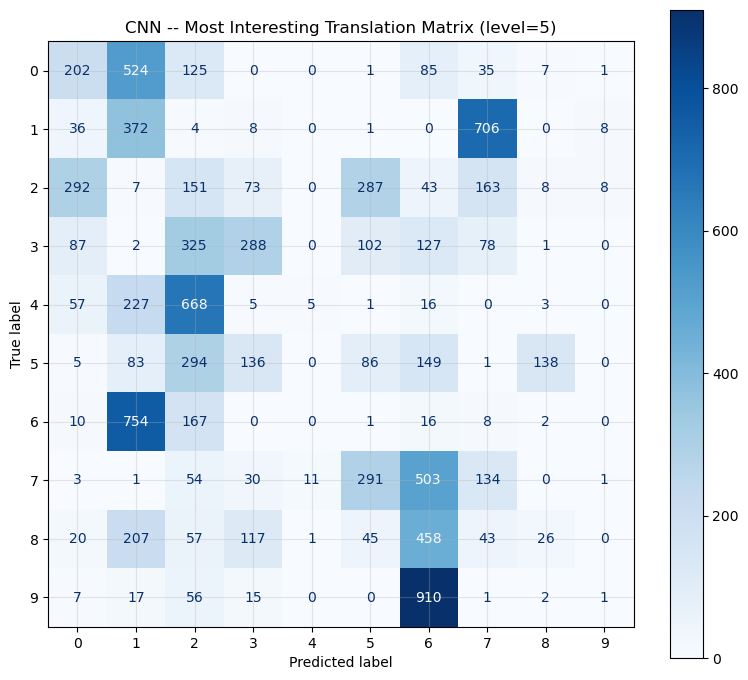


MLP -- strongest confusions for blur
perturbation  intensity  accuracy  true_digit  pred_digit  confusion_count  true_total  rate_within_true_class
        blur        4.0     24.23           9           8              974        1009               96.531219
        blur        5.0     14.74           9           8              971        1009               96.233895
        blur        4.0     24.23           5           8              857         892               96.076233
        blur        3.0     41.36           1           8             1076        1135               94.801762
        blur        5.0     14.74           5           8              837         892               93.834081
        blur        5.0     14.74           7           8              955        1028               92.898833
        blur        4.0     24.23           3           8              934        1010               92.475248
        blur        5.0     14.74           3           8              907

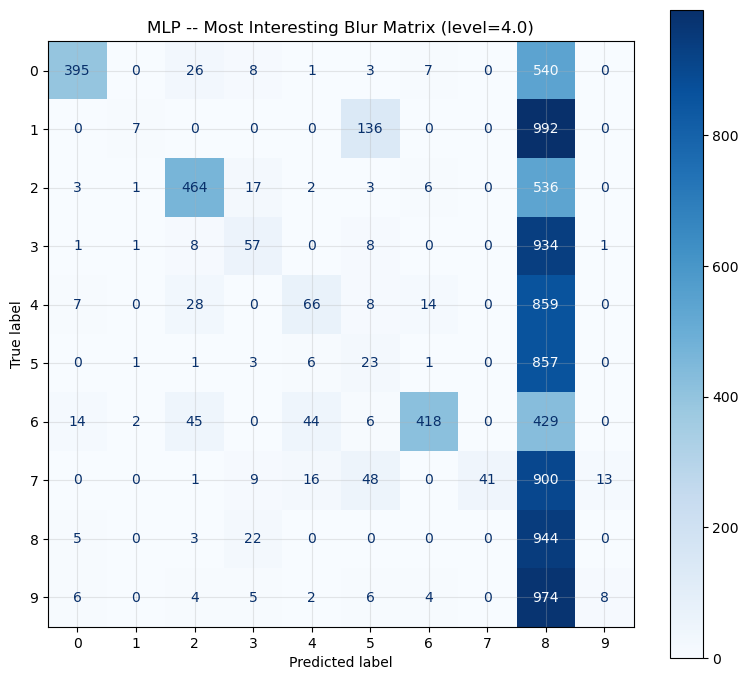


CNN -- strongest confusions for blur
perturbation  intensity  accuracy  true_digit  pred_digit  confusion_count  true_total  rate_within_true_class
        blur        5.0     17.10           3           1              941        1010               93.168317
        blur        5.0     17.10           7           1              930        1028               90.466926
        blur        5.0     17.10           5           1              795         892               89.125561
        blur        5.0     17.10           9           1              872        1009               86.422200
        blur        5.0     17.10           8           1              819         974               84.086242
        blur        5.0     17.10           4           1              806         982               82.077393
        blur        5.0     17.10           0           1              766         980               78.163265
        blur        4.0     27.58           3           1              783

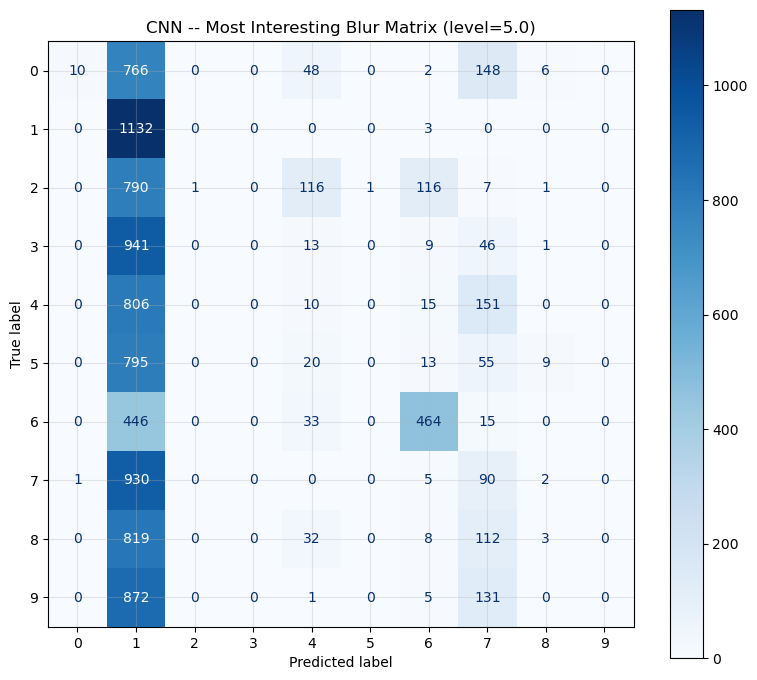


MLP -- strongest confusions for erosion
perturbation  intensity  accuracy  true_digit  pred_digit  confusion_count  true_total  rate_within_true_class
     erosion        3.0      8.93           7           5             1028        1028              100.000000
     erosion        3.0      8.93           0           5              980         980              100.000000
     erosion        3.0      8.93           1           5             1134        1135               99.911894
     erosion        3.0      8.93           2           5             1030        1032               99.806202
     erosion        3.0      8.93           3           5             1008        1010               99.801980
     erosion        3.0      8.93           9           5             1007        1009               99.801784
     erosion        3.0      8.93           4           5              980         982               99.796334
     erosion        3.0      8.93           8           5              

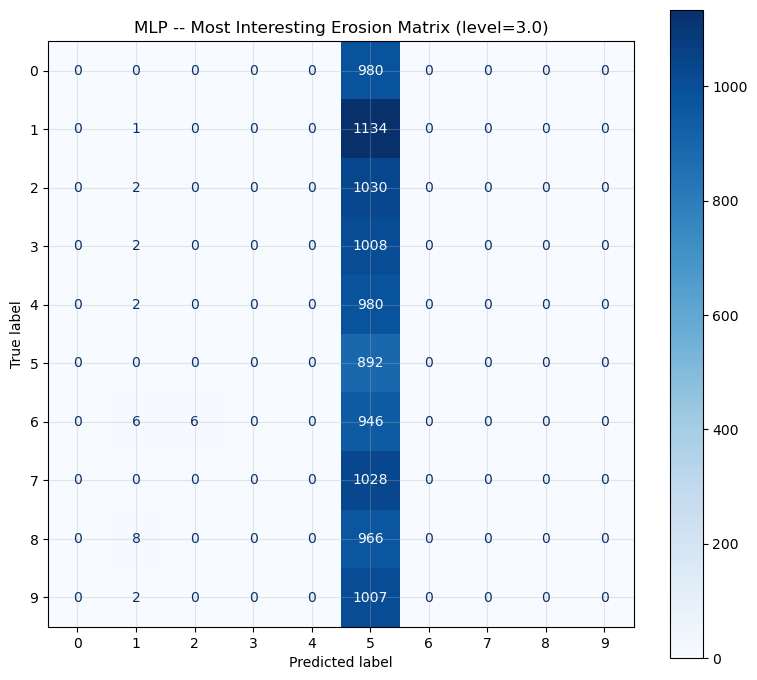


CNN -- strongest confusions for erosion
perturbation  intensity  accuracy  true_digit  pred_digit  confusion_count  true_total  rate_within_true_class
     erosion        3.0     11.46           7           1             1028        1028              100.000000
     erosion        3.0     11.46           0           1              979         980               99.897959
     erosion        3.0     11.46           4           1              980         982               99.796334
     erosion        3.0     11.46           5           1              885         892               99.215247
     erosion        3.0     11.46           2           1             1023        1032               99.127907
     erosion        3.0     11.46           9           1             1000        1009               99.108028
     erosion        3.0     11.46           8           1              961         974               98.665298
     erosion        3.0     11.46           3           1              

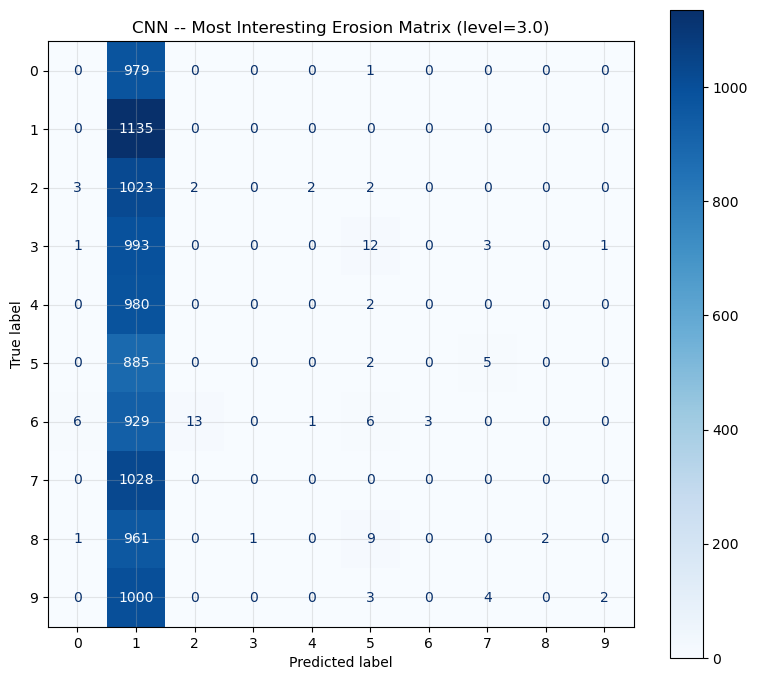

In [17]:
# Search systematically for interesting confusion matrices and confusion pairs.

analysis_specs = [
    ('MLP', mlp_model, 'rotation', rotation_angles, lambda imgs, x: perturb_rotation(imgs, x), None),
    ('CNN', cnn_model, 'rotation', rotation_angles, lambda imgs, x: perturb_rotation(imgs, x), None),
    ('MLP', mlp_model, 'translation', translation, lambda imgs, x: perturb_translation(imgs, x), lambda x: x[0]),
    ('CNN', cnn_model, 'translation', translation, lambda imgs, x: perturb_translation(imgs, x), lambda x: x[0]),
    ('MLP', mlp_model, 'blur', blur, lambda imgs, x: perturb_blur(imgs, x), None),
    ('CNN', cnn_model, 'blur', blur, lambda imgs, x: perturb_blur(imgs, x), None),
    ('MLP', mlp_model, 'erosion', erosion, lambda imgs, x: perturb_erosion(imgs, x), None),
    ('CNN', cnn_model, 'erosion', erosion, lambda imgs, x: perturb_erosion(imgs, x), None),
]

confusion_scans = {}
for model_name, model, perturbation_name, intensities, perturbation_fn, formatter in analysis_specs:
    scan_df, scan_artifacts = scan_confusions_across_levels(
        model, test_images, test_labels, perturbation_name, intensities, perturbation_fn, formatter=formatter
    )
    confusion_scans[(model_name, perturbation_name)] = (scan_df, scan_artifacts)

    print('\n' + '=' * 80)
    print(f'{model_name} -- strongest confusions for {perturbation_name}')
    if scan_df.empty:
        print('No off-diagonal confusions found.')
        continue
    print(scan_df.head(8).to_string(index=False))

    best_level = scan_df.iloc[0]['intensity']
    artifact = scan_artifacts[best_level]
    plot_confusion_matrix(
        artifact['true_labels'], artifact['predictions'],
        title=f'{model_name} -- Most Interesting {perturbation_name.capitalize()} Matrix (level={best_level})'
    )


---

## 18. Results Summary

Bring all results together for your report.


FULL RESULTS TABLE
perturbation  intensity  mlp_accuracy  cnn_accuracy  accuracy_diff
       clean        0.0         98.03         99.11           1.08
    rotation        5.0         97.42         98.78           1.36
    rotation       10.0         96.27         98.31           2.04
    rotation       15.0         94.59         97.55           2.96
    rotation       20.0         90.70         95.50           4.80
    rotation       30.0         77.60         85.96           8.36
    rotation       45.0         49.77         60.90          11.13
    rotation       90.0         10.73         16.48           5.75
    rotation      180.0         30.91         37.06           6.15
 translation        1.0         91.21         98.22           7.01
 translation        2.0         56.89         92.49          35.60
 translation        3.0         21.27         72.22          50.95
 translation        4.0          6.16         39.17          33.01
 translation        5.0          3.25     

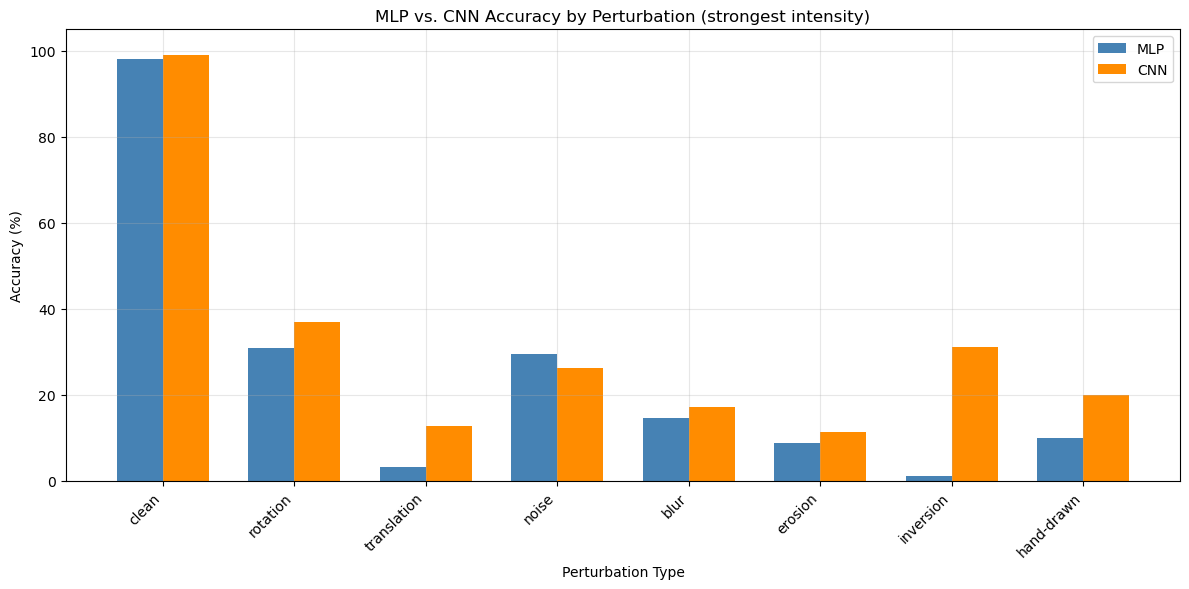

Results saved to rq2_results.csv


In [18]:
# Drop duplicate rows if a notebook cell was executed more than once.
results = results.drop_duplicates(subset=['perturbation', 'intensity'], keep='last').reset_index(drop=True)

# Display full results table
print('\n' + '=' * 70)
print('FULL RESULTS TABLE')
print('=' * 70)
print(results.to_string(index=False))

# Summary bar chart: accuracy drop per perturbation type
# (using the strongest intensity for each perturbation)
summary_rows = []
for perturbation in results['perturbation'].drop_duplicates():
    group = results[results['perturbation'] == perturbation]
    summary_rows.append(group.loc[group['intensity'].idxmax()])
summary = pd.DataFrame(summary_rows).reset_index(drop=True)

x = np.arange(len(summary))
width = 0.35
fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - width/2, summary['mlp_accuracy'], width, label='MLP', color='steelblue')
ax.bar(x + width/2, summary['cnn_accuracy'], width, label='CNN', color='darkorange')
ax.set_xlabel('Perturbation Type')
ax.set_ylabel('Accuracy (%)')
ax.set_title('MLP vs. CNN Accuracy by Perturbation (strongest intensity)')
ax.set_xticks(x)
ax.set_xticklabels(summary['perturbation'], rotation=45, ha='right')
ax.legend()
ax.set_ylim(0, 105)
plt.tight_layout()
plt.show()

# Save results
results.to_csv('rq2_results.csv', index=False)
print('Results saved to rq2_results.csv')

---

## 19. Optional Extension: Can You Build a More Robust CNN?

The template provides a simple 3-layer CNN. If you finish the core comparison early,
try modifying the CNN architecture and test whether it improves robustness.

Ideas: deeper networks, larger kernels (5x5), more filters, Global Average Pooling, or average pooling instead of max pooling.

Pick **one or two** changes, retrain on clean MNIST, and test on the same perturbed sets.  
Does the architecture matter, or are the weaknesses fundamental?

CNN_v2 parameters: 108,458
Epoch  1/20 | Train 75.84% | Val 91.82%
Epoch  5/20 | Train 96.61% | Val 96.57%
Epoch 10/20 | Train 97.88% | Val 97.88%
Epoch 15/20 | Train 98.60% | Val 98.56%
Epoch 20/20 | Train 98.98% | Val 98.82%
CNN_v2 clean test accuracy: 99.03%

CNN vs. CNN_v2 COMPARISON
         setting perturbation  intensity  original_cnn_accuracy  cnn_v2_accuracy  delta_vs_original_cnn
  Clean Test Set        clean        0.0                  99.11            99.03                  -0.08
 Rotation 45 deg     rotation       45.0                  60.90            47.66                 -13.24
Translation 3 px  translation        3.0                  72.22            97.68                  25.46
   Noise std 0.5        noise        0.5                  71.32            10.52                 -60.80
  Blur sigma 2.0         blur        2.0                  91.91            89.30                  -2.61
     Erosion 0.8      erosion        0.8                  87.55            80.42       

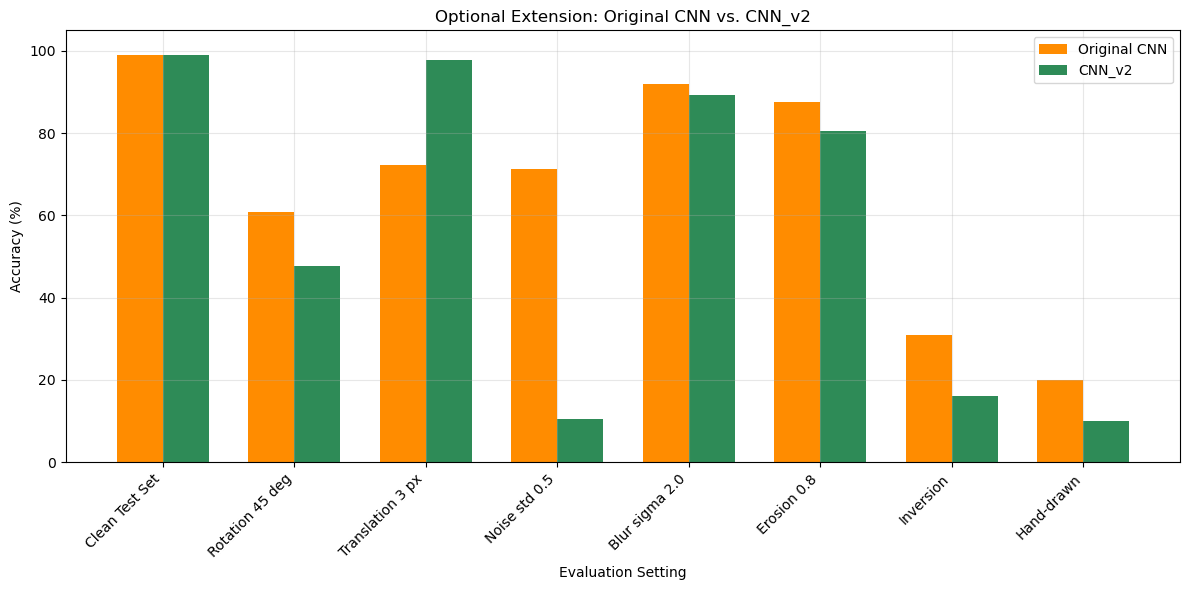

Largest change vs. original CNN: Noise std 0.5 (-60.80 percentage points).


In [19]:
# Optional extension: test whether a slightly different CNN is more robust.
# Changes compared to the original CNN:
# 1. Larger early kernels (5x5) to capture slightly bigger local stroke patterns.
# 2. Average pooling plus global average pooling for smoother spatial aggregation.

class CNN_v2(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.AvgPool2d(2),
            nn.Conv2d(32, 64, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.AvgPool2d(2),
            nn.Conv2d(64, 96, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.classifier = nn.Linear(96, 10)

    def forward(self, x):
        if x.dim() == 3:
            x = x.unsqueeze(1)
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)

    def count_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


cnn_v2_model = CNN_v2()
print(f'CNN_v2 parameters: {cnn_v2_model.count_parameters():,}')

cnn_v2_history, cnn_v2_best = train_model(cnn_v2_model, train_loader, val_loader, num_epochs=20)
cnn_v2_test_acc, cnn_v2_preds, cnn_v2_true = evaluate_model(cnn_v2_model, test_loader)
print(f'CNN_v2 clean test accuracy: {cnn_v2_test_acc:.2f}%')

reference_results = results.drop_duplicates(subset=['perturbation', 'intensity'], keep='last').reset_index(drop=True)
inversion_images = perturb_inversion(test_images)
extension_specs = [
    ('clean', 0.0, 'Clean Test Set', None, None),
    ('rotation', 45.0, 'Rotation 45 deg', perturb_rotation(test_images, 45.0), test_labels),
    ('translation', 3.0, 'Translation 3 px', translation_3, test_labels),
    ('noise', 0.5, 'Noise std 0.5', perturb_noise(test_images, 0.5), test_labels),
    ('blur', 2.0, 'Blur sigma 2.0', perturb_blur(test_images, 2.0), test_labels),
    ('erosion', 0.8, 'Erosion 0.8', perturb_erosion(test_images, 0.8), test_labels),
    ('inversion', 0.0, 'Inversion', inversion_images, test_labels),
    ('hand-drawn', 0.0, 'Hand-drawn', hand_images, hand_labels),
]

extension_rows = []
for perturbation, intensity, label, images, labels in extension_specs:
    match = reference_results[
        (reference_results['perturbation'] == perturbation) &
        (np.isclose(reference_results['intensity'].astype(float), float(intensity)))
    ]
    original_cnn_acc = float(match['cnn_accuracy'].iloc[-1]) if not match.empty else np.nan

    if perturbation == 'clean':
        cnn_v2_acc = cnn_v2_test_acc
    else:
        cnn_v2_acc, _, _, _ = evaluate_on_perturbed(cnn_v2_model, images, labels)

    extension_rows.append({
        'setting': label,
        'perturbation': perturbation,
        'intensity': intensity,
        'original_cnn_accuracy': original_cnn_acc,
        'cnn_v2_accuracy': cnn_v2_acc,
        'delta_vs_original_cnn': cnn_v2_acc - original_cnn_acc,
    })

extension_results = pd.DataFrame(extension_rows)
print('\n' + '=' * 70)
print('CNN vs. CNN_v2 COMPARISON')
print('=' * 70)
print(extension_results.to_string(index=False))

x = np.arange(len(extension_results))
width = 0.35
fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - width/2, extension_results['original_cnn_accuracy'], width, label='Original CNN', color='darkorange')
ax.bar(x + width/2, extension_results['cnn_v2_accuracy'], width, label='CNN_v2', color='seagreen')
ax.set_xlabel('Evaluation Setting')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Optional Extension: Original CNN vs. CNN_v2')
ax.set_xticks(x)
ax.set_xticklabels(extension_results['setting'], rotation=45, ha='right')
ax.set_ylim(0, 105)
ax.legend()
plt.tight_layout()
plt.show()

best_change = extension_results.iloc[extension_results['delta_vs_original_cnn'].abs().idxmax()]
print(
    f"Largest change vs. original CNN: {best_change['setting']} "
    f"({best_change['delta_vs_original_cnn']:+.2f} percentage points)."
)

---

## 20. Key Findings

Summarize your main observations here (these will feed into your report).

1. **Which perturbations hurt the MLP most?** Why? (Think about what MLPs rely on.)
   Translation hurt the MLP the most by far, especially from 2 to 4 pixels. That makes sense because the MLP seems to depend heavily on fixed pixel positions. Aswell as inversion.

2. **Which perturbations hurt the CNN most?** Why? (Think about what CNNs rely on.)
   The CNN struggled most with translation, erosion and blur. So even though it is more robust overall, it still depends a lot on MNIST-like local patterns and contrast.

3. **Where was the CNN clearly better?** What architectural property explains this?   
   The CNN was clearly better on translation, blur, erosion, and also rotation. Its local filters and weight sharing make it much less sensitive to exact pixel location than the MLP.

4. **Where did both models fail equally?** What does this tell you about their shared limitations?
   Both models degraded strongly on translation and erosion, although the CNN still performed noticeably better. This suggests that both models rely on features specific to the MNIST training distribution rather than fully learning abstract digit representations.

5. **Most surprising finding?** Something you didn't expect before running the experiments.
   The most surprising part was that at stronger noise levels the MLP slightly beat the CNN. I expected the CNN to stay better everywhere, but noise turned out to be a more mixed case.

6. **If you could add data augmentation to fix one weakness, which perturbation would you target first?**
   I would target translation first. It exposed the clearest and biggest weakness, especially for the MLP, and seems very fixable with simple augmentation.

